# Data Processing and EDA of Federal and State Workplace Injury Data

**Author:** rab  
**Last modified:** 2026-02-27

## Overview
This notebook documents the raw data processing and EDA used to examine five public workplace injury and claims sources that support our "Datasets From Five Public Workplace Injury Sources With Cross-Dataset Harmonization for Research and Modeling" and "Characterizing and Harmonizing Five Public Workplace Injury Datasets for Research and Modeling" papers' data analytics and harmonization workflows.

## Scope
- loading raw source files
- applying source-specific preprocessing and data preparation
- generating summary statistics and descriptive plots
- examining narrative text with lightweight TF-IDF analysis (as available)

## Data sources
- OSHA SIR: [Severe Injury Dashboard](https://www.osha.gov/severe-injury-reports)
- OSHA ITA: [OSHA Injury Tracking Application (ITA) Data](https://www.osha.gov/Establishment-Specific-Injury-and-Illness-Data)
- TX SV2: [Texas Institutional Medical Billing Services (SV2) Detail Information](https://data.texas.gov/dataset/Institutional-Medical-Billing-Services-SV2-Detail-/tuuc-49gz/about_data)
- OR WC: [Oregon Workers' Compensation Record Level Claims](https://catalog.data.gov/dataset/oregon-workers-compensation-record-level-claims)
- NY WC: [NY State Workers' Compensation Injury Claims](https://www.kaggle.com/datasets/thedevastator/new-york-state-workers-compensation-injury-claim)

## Expected local files (names and locations)
Place the following raw files, with names, in the same directory as this notebook before running:
- `SIR_RAW.csv`
- `SV2_RAW.csv`
- `OR_WC_RAW.csv`
- `NY_WC_RAW.csv`
- `ITA_RAW Case Detail Data 2023 through 12-31-2023.csv`
- `ITA_RAW Case Detail Data 2024 through 04-30-2025.csv`

## Reproducibility notes
This notebook is intended for paper reproducibility. It assumes the raw input files are available in the working directory with the filenames referenced. Outputs are generated in-place, and one intermediate CSV of top TF-IDF terms is written for the ITA section (due to the slowness of this particular step).


## Setup and Imports

This section imports analysis dependencies, configures plotting defaults, and loads the spaCy English model used for basic text normalization.

In [3]:
# Core analysis, visualization, text-processing, and fuzzy-matching imports.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import os
import re
import spacy
import string
from rapidfuzz import process, fuzz
from sklearn.feature_extraction.text import TfidfVectorizer

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")

sns.set_theme(style="whitegrid", palette="viridis")

## Data Ingestion

Load the five raw source datasets used throughout the notebook.

Expected local input files:
- **SIR_RAW.csv**: OSHA Severe Injury Reports
- **SV2_RAW.csv**: Texas institutional medical billing records
- **OR_WC_RAW.csv**: Oregon workers’ compensation claims
- **NY_WC_RAW.csv**: New York workers’ compensation claims
- **ITA raw case-detail files**: multiple OSHA ITA extracts concatenated below

The ingestion cells are intentionally explicit so that each source can be inspected independently before downstream processing.

In [4]:
# Load OSHA Severe Injury Reports.
df_sir_raw = pd.read_csv('SIR_RAW.csv', low_memory=False)

In [5]:
df_sir_raw.head()

,ID,UPA,EventDate,Employer,Address1,Address2,City,State,Zip,Latitude,...,NatureTitle,Part of Body,Part of Body Title,Event,EventTitle,Source,SourceTitle,Secondary Source,Secondary Source Title,FederalState
0,2015010015,931176,1/1/2015,FCI Otisville Federal Correctional Institution,Two Mile Drive,NaN,OTISVILLE,NEW YORK,10963.0,41.46,...,Fractures,513,Lower leg(s),1214,Injured by physical contact with person while ...,5721,Co-worker,5772.0,Inmate or detainee in custody,1
1,2015010016,930267,1/1/2015,Kalahari Manufacturing LLC,171 Progress Drive,NaN,LAKE DELTON,WISCONSIN,53940.0,43.59,...,Second degree heat (thermal) burns,519,"Leg(s), n.e.c.",317,"Ignition of vapors, gases, or liquids",7261,"Welding, cutting, and blow torches",NaN,NaN,1
2,2015010018,929823,1/1/2015,Schneider National Bulk Carrier,420 CORAOPOLIS ROAD,NaN,CORAOPOLIS,PENNSYLVANIA,15108.0,40.49,...,"Traumatic injuries and disorders, unspecified",9999,Nonclassifiable,4331,Other fall to lower level less than 6 feet,8421,"Semi, tractor-trailer, tanker truck",741.0,Ladders-fixed,1
3,2015010019,929711,1/1/2015,PEPSI BOTTLING GROUP INC.,4541 HOUSTON AVE.,NaN,MACON,GEORGIA,31206.0,32.77,...,"Soreness, pain, hurt-nonspecified injury",510,"Leg(s), unspecified",640,Caught in or compressed by equipment or object...,8623,Pallet jack-powered,8420.0,"Truck-motorized freight hauling and utility, u...",1
4,2015010020,929642,1/1/2015,North American Pipe Corporation,210 South Arch Street,NaN,JANESVILLE,WISCONSIN,53545.0,42.67,...,Fractures,4429,"Finger(s), fingernail(s), n.e.c.",6411,Caught in running equipment or machinery durin...,350,"Metal, woodworking, and special material machi...",NaN,NaN,1


In [6]:
df_sir_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 97328 entries, 0 to 97327
Data columns (total 28 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      97328 non-null  int64  
 1   UPA                     97328 non-null  int64  
 2   EventDate               97328 non-null  object 
 3   Employer                97328 non-null  object 
 4   Address1                97310 non-null  object 
 5   Address2                8636 non-null   object 
 6   City                    97311 non-null  object 
 7   State                   97328 non-null  object 
 8   Zip                     97304 non-null  float64
 9   Latitude                97217 non-null  float64
 10  Longitude               97217 non-null  float64
 11  Primary NAICS           97326 non-null  object 
 12  Hospitalized            97328 non-null  float64
 13  Amputation              97321 non-null  float64
 14  Loss of Eye             97323 non-null

In [7]:
df_sir_raw['Loss of Eye'].value_counts()

Loss of Eye
0.0     97101
1.0       214
9.0         6
8.0         1
10.0        1
Name: count, dtype: int64

In [8]:
# Load Texas SV2 billing-line data.
df_sv2_raw = pd.read_csv('SV2_RAW.csv', low_memory=False)

In [9]:
df_sv2_raw.head()

,Bill Selection Date,Bill ID,Bill Detail ID,Line Number,HCPCS Line Procedure Billed Code,First HCPCS Modifier Billed Code,Second HCPCS Modifier Billed Code,Third HCPCS Modifier Billed Code,Fourth HCPCS Modifier Billed Code,Procedure Description,...,Service Adjustment Amount 3,Service Adjustment Units 3,Service Adjustment Group Code 4,Service Adjustment Reason Code 4,Service Adjustment Amount 4,Service Adjustment Units 4,Service Adjustment Group Code 5,Service Adjustment Reason Code 5,Service Adjustment Amount 5,Service Adjustment Units 5
0,01/02/2021,84960741,239611221,3,G0156,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,01/02/2021,84960741,239611222,4,G0156,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,01/02/2021,84960741,239611223,5,G0156,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,01/02/2021,84960741,239611220,2,G0156,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,01/02/2021,84960741,239611219,1,G0156,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Load Oregon workers' compensation claims data.
df_or_wc_raw = pd.read_csv('OR_WC_RAW.csv', low_memory=False)

In [11]:
df_or_wc_raw.head()

,Claim Number,Claim Reference Year,Date of Injury,County of Injury,Age Range,Gender,Occupation Code,Occupation Description,Tenure,Nature of Injury Code,...,NAICS Code (Description),Employer Number,Employer Location Number,Number of employees,Employer Name,Employer Address 1,Employer Address 2,Employer City,Employer State,Employer Zip Code
0,Claim203890,2022,2021Q4,Morrow,Over 65,M,493031,Bus and Truck Mechanics and Diesel Engine Spec...,6th-10th years,1839,...,CORN FARMING,8871014,3,50-99,FREDERICKSON FARMING LLC,NaN,80702 PATERSON FERRY RD,IRRIGON,97844,97844
1,Claim120254,2018,2018Q3,Morrow,25-34,M,452093,"Farmworkers, Farm and Ranch Animals",Not available,9,...,WHEAT FARMING,1466499,0,11-49,CRUM FARMING INC,NaN,68634 CRUM RD,IONE,97843,97843
2,Claim154653,2020,2020Q1,Malheur,45-54,M,452093,"Farmworkers, Farm and Ranch Animals",Not available,1238,...,OILSEED AND GRAIN FARMING,EmpX6823033,Redacted,1-10,Redacted,Redacted,Redacted,Redacted,Redacted,Redacted
3,Claim35135,2015,2014Q4,Morrow,Over 65,M,533032,"Truck Drivers, Heavy and Tractor-Trailer",Not available,1232,...,WHEAT FARMING,1466499,0,11-49,CRUM FARMING INC,NaN,68634 CRUM RD,IONE,97843,97843
4,Claim157112,2020,2020Q4,Marion,18-24,M,131041,"Compliance Officers, Except Agriculture, Const...",4th-5th years,148,...,OILSEED AND GRAIN FARMING,EmpX5079145,Redacted,1-10,Redacted,Redacted,Redacted,Redacted,Redacted,Redacted


In [12]:
# Load New York workers' compensation claims data.
df_ny_wc_raw = pd.read_csv('NY_WC_RAW.csv', low_memory=False)

In [13]:
df_ny_wc_raw.head()

,index,Assembly Date,Accident Date,Age at Injury,Gender,Controverted Date,WCIO Part Of Body Code,WCIO Part Of Body Description,WCIO Nature of Injury Code,WCIO Nature of Injury Description,...,OIICS Injury Source Description,OIICS Event Exposure Code,OIICS Event Exposure Description,OIICS Secondary Source Code,OIICS Secondary Source Description,Highest Process,Hearing Count,Claim Injury Type,Claim Type,Carrier Type
0,0,01/06/2000,12/08/1998,49.0,M,NaN,NaN,NaN,NaN,NaN,...,Containers--nonpressurized,22*,Overexertion,11*,Containers--nonpressurized,Hearing - Judge,1.0,PPD SCH LOSS,Workers Compensation,SIF
1,1,01/10/2000,10/29/1999,30.0,M,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Administrative Determination,0.0,TEMPORARY,Workers Compensation,PRIVATE
2,2,01/13/2000,12/27/1999,46.0,F,NaN,NaN,NaN,NaN,NaN,...,Furniture,13*,Fall on same level,23*,Furniture,Hearing - Judge,3.0,PPD SCH LOSS,Workers Compensation,PRIVATE
3,3,01/10/2000,11/28/1999,59.0,F,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,Conciliation - Desk Decision,0.0,TEMPORARY,Workers Compensation,SIF
4,4,01/03/2000,11/01/1999,72.0,F,NaN,NaN,NaN,NaN,NaN,...,Person--other than injured or ill worker,61*,Assaults and violent acts by person(s),57*,Person--other than injured or ill worker,Hearing - Judge,2.0,PPD SCH LOSS,Workers Compensation,SELF PUBLIC


In [ ]:
# Read and concatenate multiple OSHA ITA case-detail extracts into a single dataframe.
file_list = ["ITA_RAW Case Detail Data 2023 through 12-31-2023.csv", "ITA_RAW Case Detail Data 2024 through 04-30-2025.csv", ]

read_kwargs = {
    #"dtype_backend": "pyarrow",
    "low_memory": False,
    "encoding": "ISO-8859-1"
}

# Read each ITA extract separately, then stack them row-wise.
df_list = [pd.read_csv(os.path.join('', f), **read_kwargs) for f in file_list]
df_ita_raw = pd.concat(df_list, ignore_index=True).reset_index(drop=True)
df_ita_raw = df_ita_raw.drop(['new_incident_location',
       'new_nar_before_incident', 'new_nar_what_happened',
       'new_nar_injury_illness', 'new_nar_object_substance'], axis=1)

In [15]:
df_ita_raw.head()

,id,establishment_id,establishment_name,ein,company_name,street_address,city,state,zip_code,naics_code,...,time_unknown,date_of_death,created_timestamp,year_filing_for,NEW_NAR_WHAT_HAPPENED,NEW_NAR_BEFORE_INCIDENT,NEW_INCIDENT_LOCATION,NEW_NAR_INJURY_ILLNESS,NEW_NAR_OBJECT_SUBSTANCE,NEW_INCIDENT_DESCRIPTION
0,446827.0,41940,AristaCare at Meadow Springs,204755042,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462.0,623110.0,...,0.0,NaN,26FEB24:20:47:00,2023.0,needle stick to left thumb after administering...,getting medication ready to administer to resi...,Resident room,needle stick,needle,left thumb needle stick after giving medicatio...
1,448949.0,41940,AristaCare at Meadow Springs,204755042,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462.0,623110.0,...,1.0,NaN,26FEB24:21:03:00,2023.0,While attempting to give care for resident emp...,Giving care to the resident,Resident room,Left shoulder strain,resident,left should strain from trying to turn resident
2,449370.0,41940,AristaCare at Meadow Springs,204755042,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462.0,623110.0,...,0.0,NaN,26FEB24:21:12:00,2023.0,While reaching employee tried to brace herself...,Trying to reach to put her schedule on the table,rehab office,right wrist and shoulder strain left knee pain,the chair,right shoulder and arm strain and left knee pa...
3,449479.0,41940,AristaCare at Meadow Springs,204755042,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462.0,623110.0,...,0.0,NaN,26FEB24:21:16:00,2023.0,Employee entered shower room to wash hands and...,entered shower room to wash hands,shower room,Lower back pain left side numbness,wet floor,strain of lumbar region and neck muscle
4,450502.0,41940,AristaCare at Meadow Springs,204755042,AristaCare at Meadow Springs LLC,845 Germantown Pike,Plymouth Meeting,PA,19462.0,623110.0,...,0.0,NaN,26FEB24:21:28:00,2023.0,Administered insulin injection to resident upo...,Getting ready to administer insulin to resident,Resident room,Needle stick,needle,left second finger needle stick


### Helper Functions

Reusable utilities for plotting, narrative preprocessing, and TF-IDF term extraction are defined once here and reused across source-specific sections.

In [16]:
# Standard horizontal barplot helper used throughout the notebook.
def create_barplot(data, title, xlabel, ylabel, figsize=(10, 7)):
    plt.figure(figsize=figsize)
    sns.barplot(x=data.values, y=data.index, hue=data.index, palette='viridis', legend=False)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [17]:
# Lightweight text normalization for narrative fields using spaCy lemmatization.
def preprocess_text_spacy(text):
    doc = nlp(str(text).lower())
    tokens = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and token.is_alpha]
    return " ".join(tokens)

In [18]:
# Extract the highest-weight TF-IDF terms from the processed narrative text.
def get_top_tfidf_terms(df, max_features=100, max_top_terms=25):
    vectorizer = TfidfVectorizer(max_features=max_features)
    tfidf_matrix = vectorizer.fit_transform(df['processed_txt'])
    
    tfidf_scores = tfidf_matrix.sum(axis=0).A1
    terms = vectorizer.get_feature_names_out()
    tfidf_df = pd.DataFrame({'term': terms, 'tfidf': tfidf_scores})
    top_terms = tfidf_df.sort_values(by='tfidf', ascending=False).head(max_top_terms)

    return top_terms

#### Years to Subset

Define the inclusive analytic year window used for the source-level subsets below.

In [19]:
START_YEAR = 2015
END_YEAR = 2024

## OSHA Severe Injury Reports (SIR)

This section preprocesses the OSHA Severe Injury Reports data, derives calendar fields, constructs a serious-incident indicator, and summarizes major injury characteristics.

In [20]:
# Create derived calendar fields and a broad serious-incident flag for SIR.
df = df_sir_raw.copy()

df['EventDate'] = pd.to_datetime(df['EventDate'])
df['Year'] = df['EventDate'].dt.year
df['Month'] = df['EventDate'].dt.month
df['DayOfWeek'] = df['EventDate'].dt.dayofweek  #where 0=Monday, 6=Sunday
df['DayName'] = df['EventDate'].dt.day_name()

df = df[(df["EventDate"].dt.year >= START_YEAR) &
        (df["EventDate"].dt.year <= END_YEAR)]

for col in ["Hospitalized", "Amputation", "Loss of Eye"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

# creating a flag for severity given these serious indicent categories
severity_cols = ['Hospitalized', 'Amputation', 'Loss of Eye']
df['SeriousIncident'] = df[severity_cols].sum(axis=1) > 0

In [21]:
# Basic SIR completeness summary for selected analytic fields.
def sir_stats(df):
    total = len(df)
    missing_naics = df['Primary NAICS'].isna().mean() * 100
    missing_injury = df['NatureTitle'].isna().mean() * 100
    missing_narr = df['Final Narrative'].isna().mean() * 100
    completeness = 100 - (missing_naics + missing_injury + missing_narr)
    return total, missing_naics, missing_injury, missing_narr, completeness

In [22]:
sir_stats(df)

(97328,
 np.float64(0.0020549071181982575),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(99.9979450928818))

In [ ]:
# df.sort_values("EventDate", ascending=True)

### Filter for Physical Injuries

Apply a simple keyword-based filter to separate likely physical injury events from obvious non-injury or medical-event records.

In [23]:
# Heuristic keyword filters used for focused inspection of likely physical injury events.
injury_keywords = [
    "caught", "struck", "fall", "burn", "crushed", "fracture",
    "laceration", "amputation", "pinched", "collision", "hit",
    "cut", "entanglement", "electrical", "machine", "equipment"
]

exclude_keywords = [
    "non-injury", "no injury", "medical event", "heart attack",
    "illness", "sudden illness"
]

df_filtered = df[df["EventTitle"].notna()].copy()

pattern_excl = "|".join(exclude_keywords)
pattern_injury = "|".join(injury_keywords)
df_filtered = df_filtered[~df_filtered["EventTitle"].str.contains(pattern_excl, case=False, na=False)]
df_filtered = df_filtered[df_filtered["EventTitle"].str.contains(pattern_injury, case=False, na=False)]

### Text Processing and TF-IDF Analysis

Normalize SIR narratives with spaCy lemmatization and summarize salient terms using TF-IDF over the processed text field.

In [24]:
# Preprocess SIR narratives and compute top TF-IDF terms.
df['processed_txt'] = df['Final Narrative'].apply(preprocess_text_spacy)
top_terms_sir = get_top_tfidf_terms(df, max_features=100, max_top_terms=25)

### Visualizations

Generate descriptive plots for common injury attributes, narrative term frequencies, and selected severity-related comparisons.

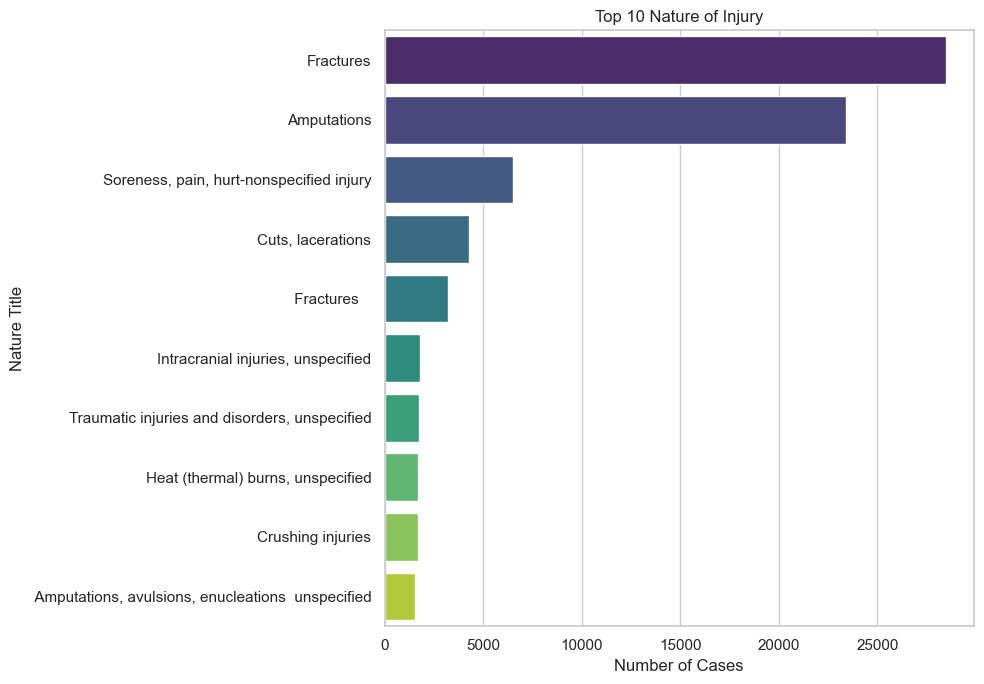

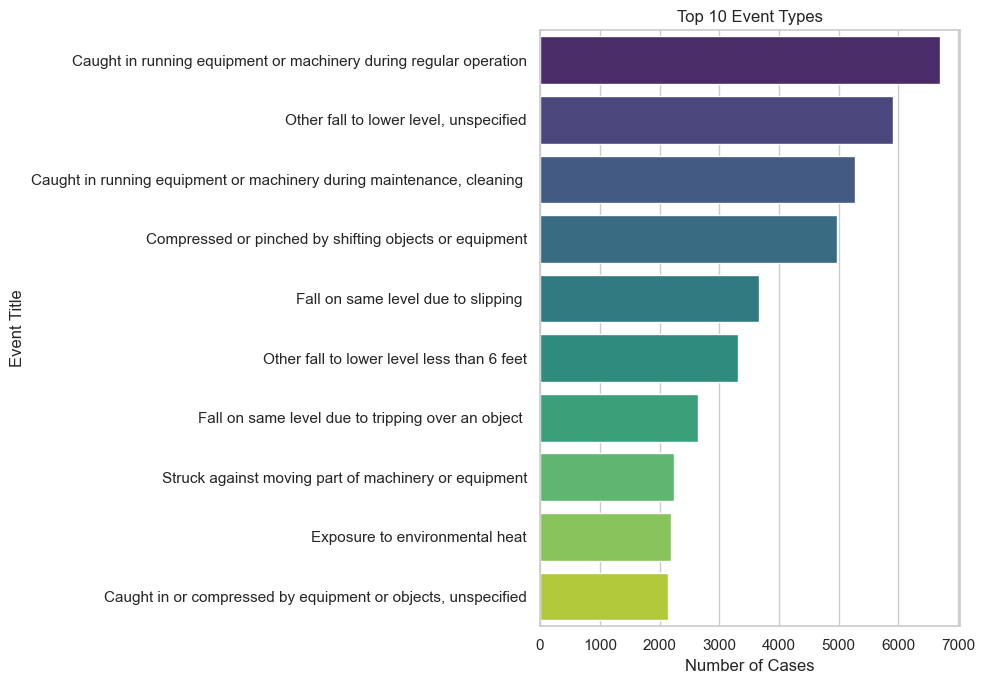

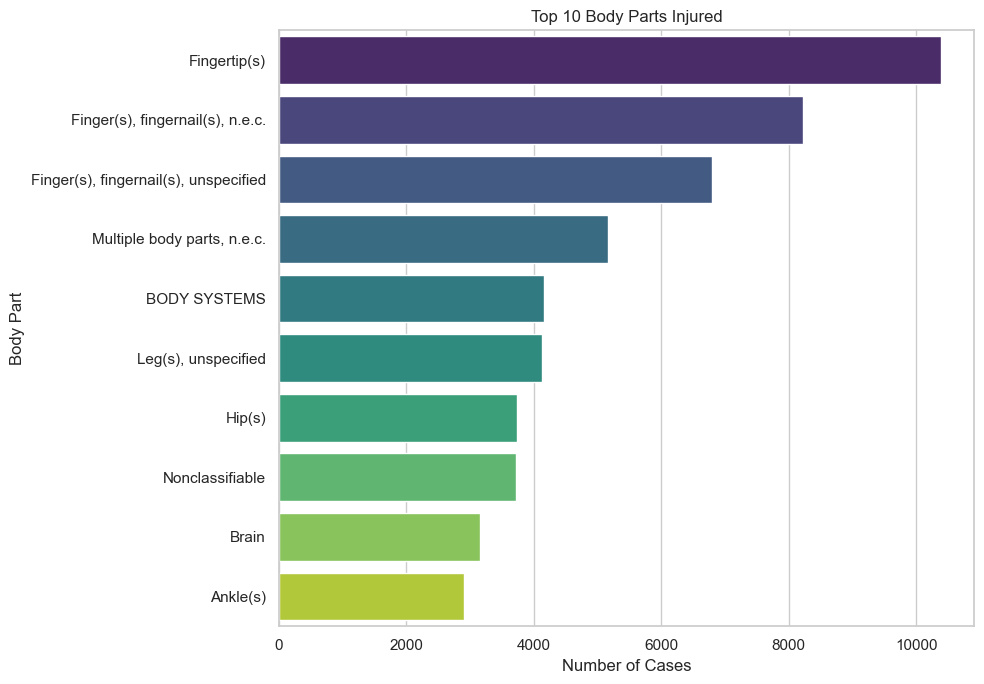

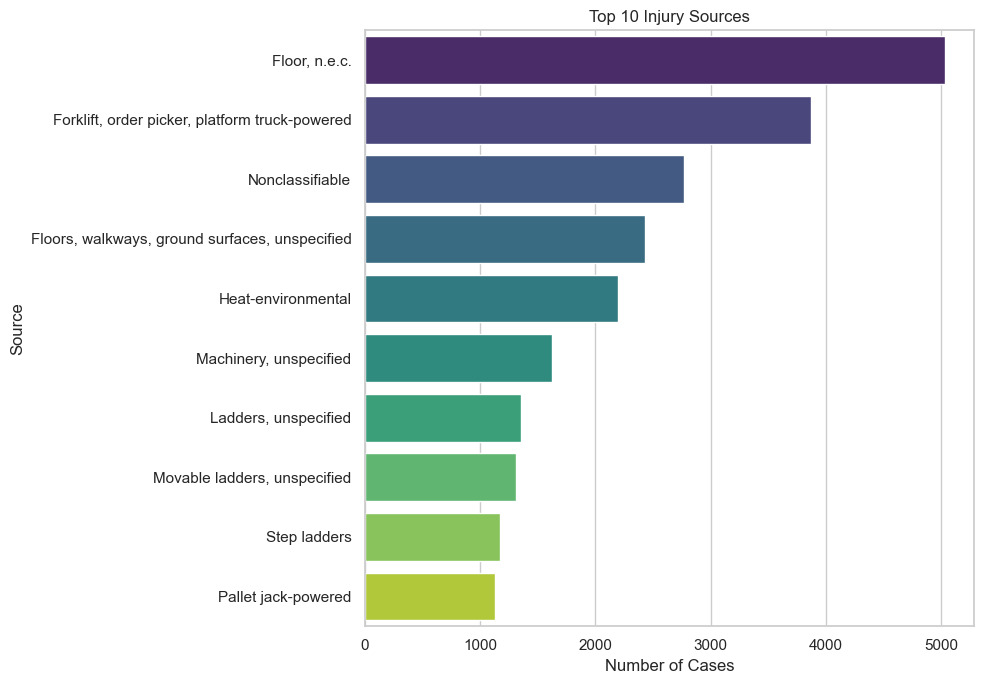

In [25]:
top_nature = df['NatureTitle'].value_counts().nlargest(10)
create_barplot(top_nature, "Top 10 Nature of Injury", "Number of Cases", "Nature Title")

top_event = df['EventTitle'].value_counts().nlargest(10)
create_barplot(top_event, "Top 10 Event Types", "Number of Cases", "Event Title")

top_body = df["Part of Body Title"].value_counts().head(10)
create_barplot(top_body, "Top 10 Body Parts Injured", "Number of Cases", "Body Part")

top_source = df["SourceTitle"].value_counts().head(10)
create_barplot(top_source, "Top 10 Injury Sources", "Number of Cases", "Source")

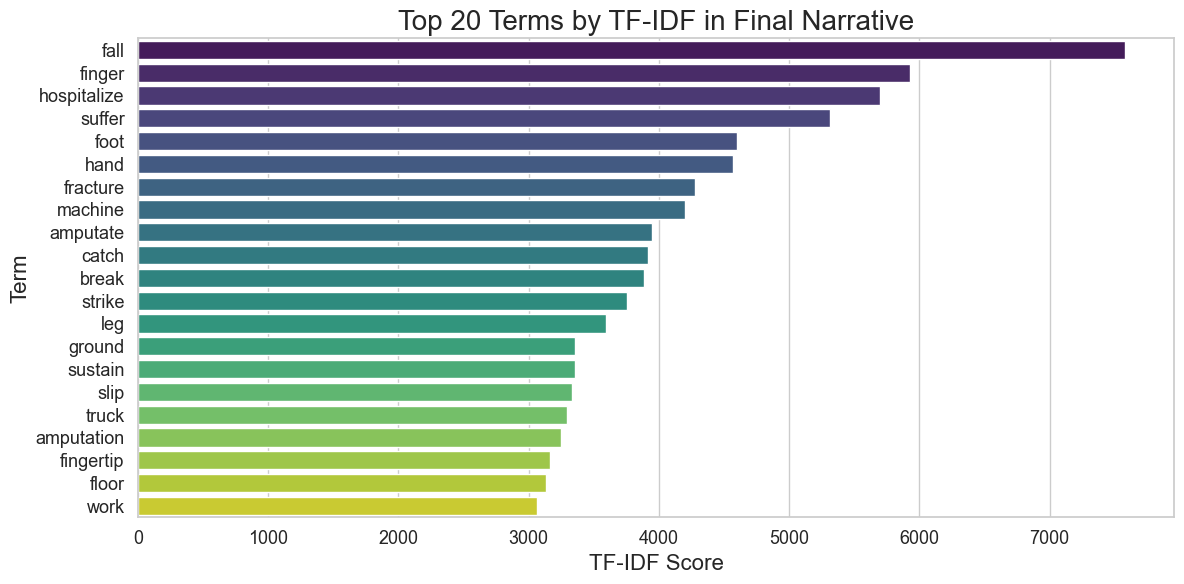

In [26]:
exclude_terms = ['employee', 'right', 'left', 'result']
filtered_terms = top_terms_sir[~top_terms_sir['term'].str.contains('|'.join(exclude_terms), case=False, na=False)]

plt.figure(figsize=(12, 6))
ax = sns.barplot(x='tfidf', y='term', data=filtered_terms, hue='term', palette='viridis', legend=False)
plt.title('Top 20 Terms by TF-IDF in Final Narrative', fontsize=20)
plt.xlabel('TF-IDF Score', fontsize=16)
plt.ylabel('Term', fontsize=16)
ax.tick_params(axis='both', labelsize=13)
plt.tight_layout()

plt.savefig('plots/sir_top_20_tfidf_terms.png', dpi=300, bbox_inches='tight')
plt.show()

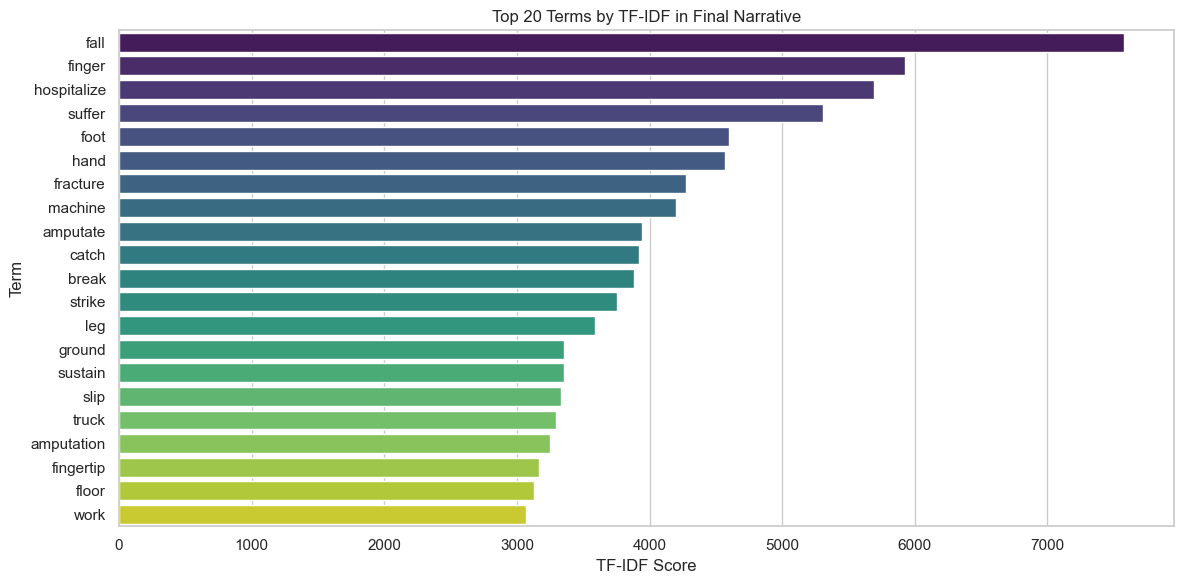

In [27]:

plt.figure(figsize=(12, 6))
sns.barplot(x='tfidf', y='term', data=filtered_terms, hue='term', palette='viridis', legend=False)
plt.title('Top 20 Terms by TF-IDF in Final Narrative')
plt.xlabel('TF-IDF Score')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

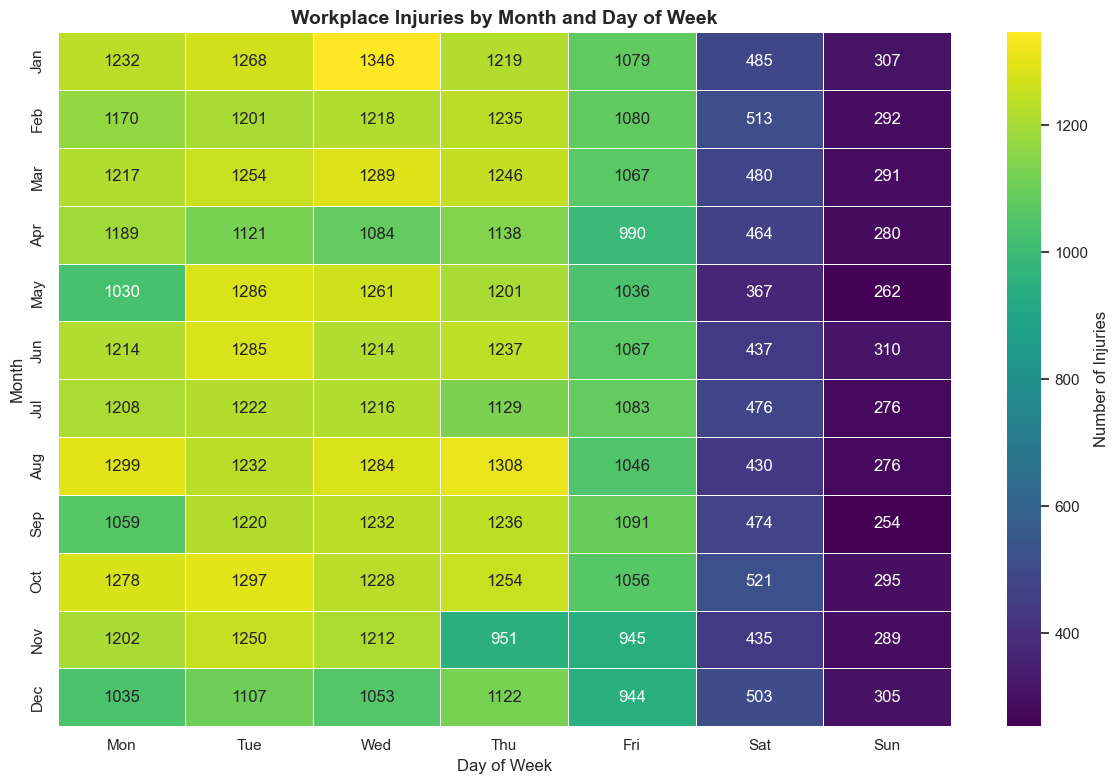

In [28]:
fig, ax = plt.subplots(figsize=(12, 8))
heatmap_data = df_filtered.groupby(['Month', 'DayOfWeek']).size().unstack(fill_value=0)

day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.columns = [day_names[i] for i in heatmap_data.columns]
heatmap_data.index = [month_names[i-1] for i in heatmap_data.index]

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of Injuries'})
ax.set_title('Workplace Injuries by Month and Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Month', fontsize=12)
plt.tight_layout()
plt.show()

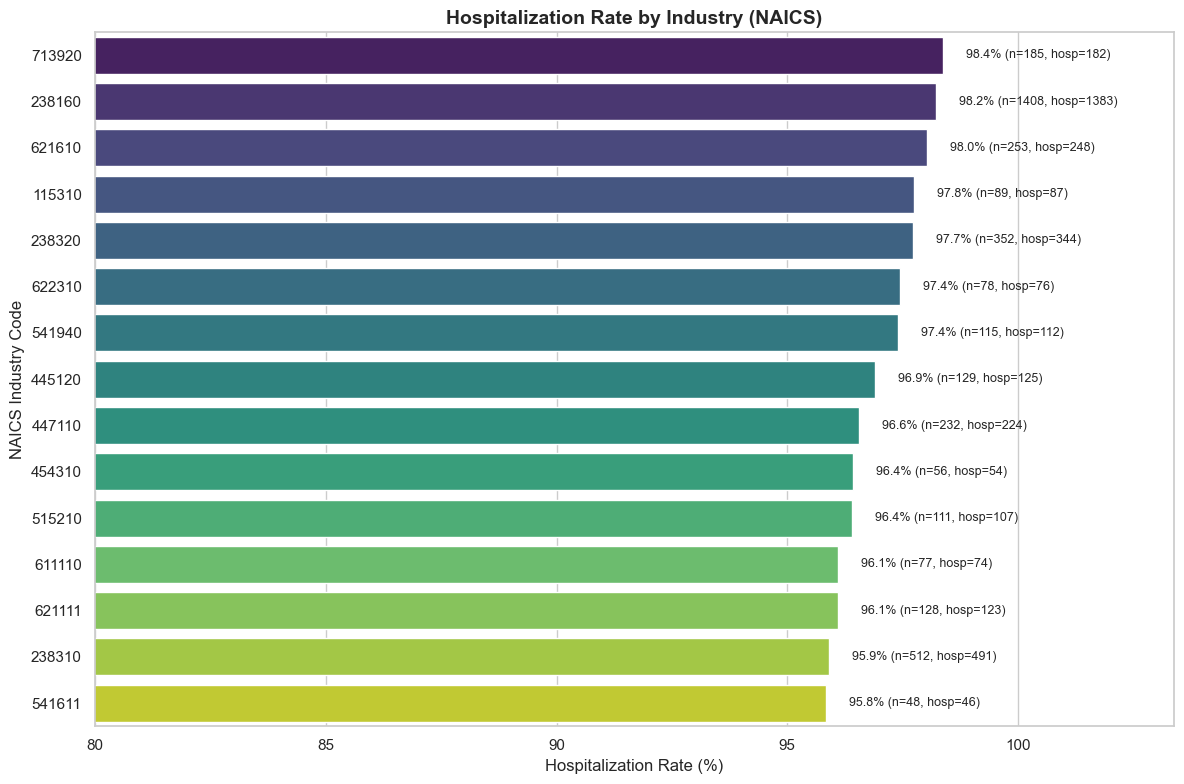

In [29]:
# Summarize injury counts and hospitalizations by industry before calculating hospitalization rates.
hosp_by_industry = df.groupby('Primary NAICS').agg(total_injuries=('ID', 'count'),
                                                   hospitalizations=('Hospitalized', 'sum')
                                                   ).reset_index()

hosp_by_industry = hosp_by_industry[
    (hosp_by_industry['hospitalizations'] <= hosp_by_industry['total_injuries']) &
    (hosp_by_industry['total_injuries'] >= 10) &
    ((hosp_by_industry['total_injuries'] - hosp_by_industry['hospitalizations']) >= 2)
]

hosp_by_industry['hosp_rate'] = (hosp_by_industry['hospitalizations'] / hosp_by_industry['total_injuries'] * 100)

# Focus the plot on the industries with the highest observed hospitalization rates after filtering.
top_hosp = hosp_by_industry.nlargest(15, 'hosp_rate')

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=top_hosp, y='Primary NAICS', x='hosp_rate', 
            hue='Primary NAICS', palette='viridis', legend=False, ax=ax)
ax.set_title('Hospitalization Rate by Industry (NAICS)', fontsize=14, fontweight='bold')
ax.set_xlabel('Hospitalization Rate (%)', fontsize=12)
ax.set_ylabel('NAICS Industry Code', fontsize=12)
ax.set_xlim(80, top_hosp['hosp_rate'].max() + 5)

for i, (rate, total, hosp) in enumerate(zip(top_hosp['hosp_rate'], top_hosp['total_injuries'], top_hosp['hospitalizations'])):
    ax.text(rate + 0.5, i, f'{rate:.1f}% (n={total}, hosp={hosp})', va='center', fontsize=9)

plt.tight_layout()
plt.show()

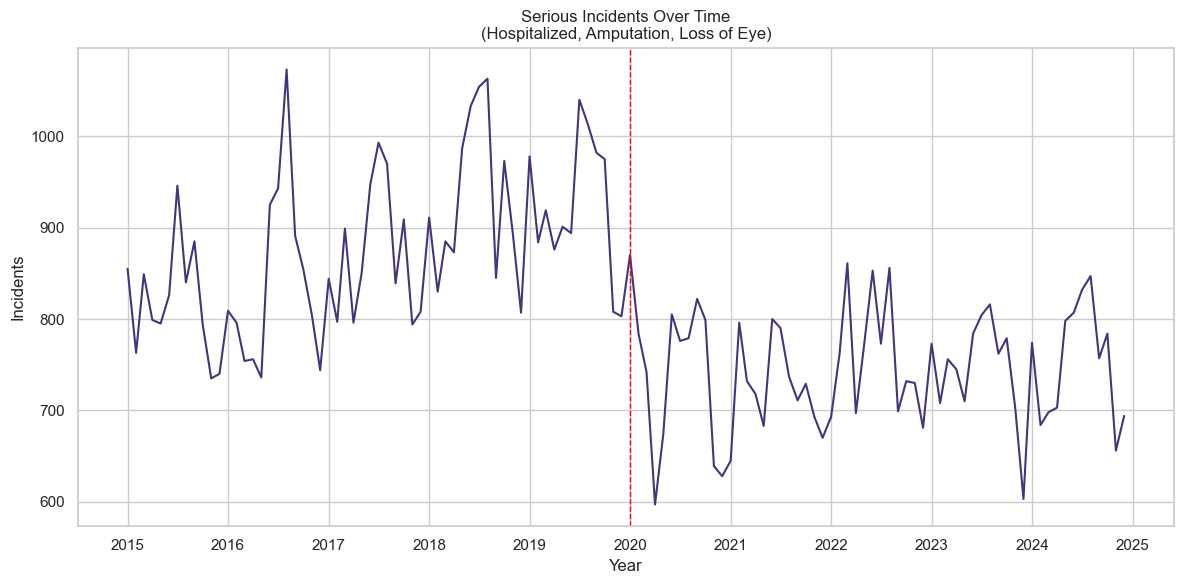

In [30]:
filtered_serious = df[df['SeriousIncident']]
monthly = (filtered_serious.groupby(["Year", "Month"]).size().reset_index(name="incident_count"))
monthly["date"] = pd.to_datetime(monthly[["Year", "Month"]].assign(day=1))

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="date", y="incident_count")
plt.title("Serious Incidents Over Time\n(Hospitalized, Amputation, Loss of Eye)", ha='center')
plt.axvline(x=pd.to_datetime("2020-01-01"), color='red', linestyle='--', linewidth=1)
plt.ylabel("Incidents")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [31]:
summary = f"""
SIR ANALYSIS SUMMARY

Total incidents: {len(df):,}
Unique employers: {df['Employer'].nunique():,}
Date range: {df['EventDate'].min()} to {df['EventDate'].max()}

Severe Outcomes:
- Total hospitalized: {df['Hospitalized'].sum():,.0f}
- Total amputations: {df['Amputation'].sum():,.0f}
- Total loss of eye: {df['Loss of Eye'].sum():,.0f}

Top Nature of Injury:
{top_nature.to_string()}

Top Body Parts Injured:
{top_body.to_string()}
"""

print(summary)


SIR ANALYSIS SUMMARY

Total incidents: 97,328
Unique employers: 66,620
Date range: 2015-01-01 00:00:00 to 2024-12-31 00:00:00

Severe Outcomes:
- Total hospitalized: 79,362
- Total amputations: 25,807
- Total loss of eye: 286

Top Nature of Injury:
NatureTitle
Fractures                                             28481
Amputations                                           23400
Soreness, pain, hurt-nonspecified injury               6522
Cuts, lacerations                                      4266
 Fractures                                             3216
Intracranial injuries, unspecified                     1800
Traumatic injuries and disorders, unspecified          1730
Heat (thermal) burns, unspecified                      1723
Crushing injuries                                      1723
 Amputations, avulsions, enucleations  unspecified     1569

Top Body Parts Injured:
Part of Body Title
Fingertip(s)                             10390
Finger(s), fingernail(s), n.e.c.          8232


## OSHA Injury Tracking Application (ITA)

This section processes the concatenated OSHA ITA case-detail extracts, restricts the date range, and examines structured and narrative fields relevant to injury characterization.

In [32]:
# Start ITA processing from a fresh copy of the concatenated raw data.
df = df_ita_raw.copy()

In [33]:
# Parse the incident date and subset to the analytic year window.
df["date_of_incident"] = pd.to_datetime(df["date_of_incident"], format="%m/%d/%Y")
df = df[(df["date_of_incident"].dt.year >= START_YEAR) &
        (df["date_of_incident"].dt.year <= END_YEAR)]

In [34]:
print(df["date_of_incident"].min(), "--", df["date_of_incident"].max())

2022-02-26 00:00:00 -- 2024-12-31 00:00:00


In [35]:
# Basic ITA completeness summary for selected analytic fields.
def ita_stats(df):
    total = len(df)
    missing_naics = df['naics_code'].isna().mean() * 100
    missing_injury = df['NEW_NAR_INJURY_ILLNESS'].isna().mean() * 100
    missing_narr = df['NEW_INCIDENT_DESCRIPTION'].isna().mean() * 100
    completeness = 100 - (missing_naics + missing_injury + missing_narr)
    return total, missing_naics, missing_injury, missing_narr, completeness

In [36]:
ita_stats(df)

(1642511,
 np.float64(0.0),
 np.float64(45.76973913721126),
 np.float64(0.07829475723450253),
 np.float64(54.15196610555424))

### Text Processing and TF-IDF Analysis

Combine the available ITA narrative components, preprocess the text, and extract high-weight TF-IDF terms for descriptive review.

**Runtime note**

The spaCy-based narrative preprocessing in this section can be slow on full ITA extracts. Runtime depends on hardware, environment, and dataset size.

In [38]:
df['combined_narrative'] = (
    df['NEW_NAR_BEFORE_INCIDENT'].fillna('') + ' ' +
    df['NEW_NAR_INJURY_ILLNESS'].fillna('') + ' ' +
    df['NEW_INCIDENT_DESCRIPTION'].fillna('')
)

df['processed_txt'] = df['combined_narrative'].apply(preprocess_text_spacy)
top_terms_ita = get_top_tfidf_terms(df, max_features=100, max_top_terms=25)

In [39]:
# Persist top ITA TF-IDF terms for review or downstream reuse.
top_terms_ita.to_csv("top_terms_ita.csv", index=False)
#top_terms_ita = pd.read_csv("top_terms_ita.csv", low_memory=False)

### Visualizations

Generate descriptive plots for injury types, locations, involved objects/substances, establishments, and state-level incident counts.

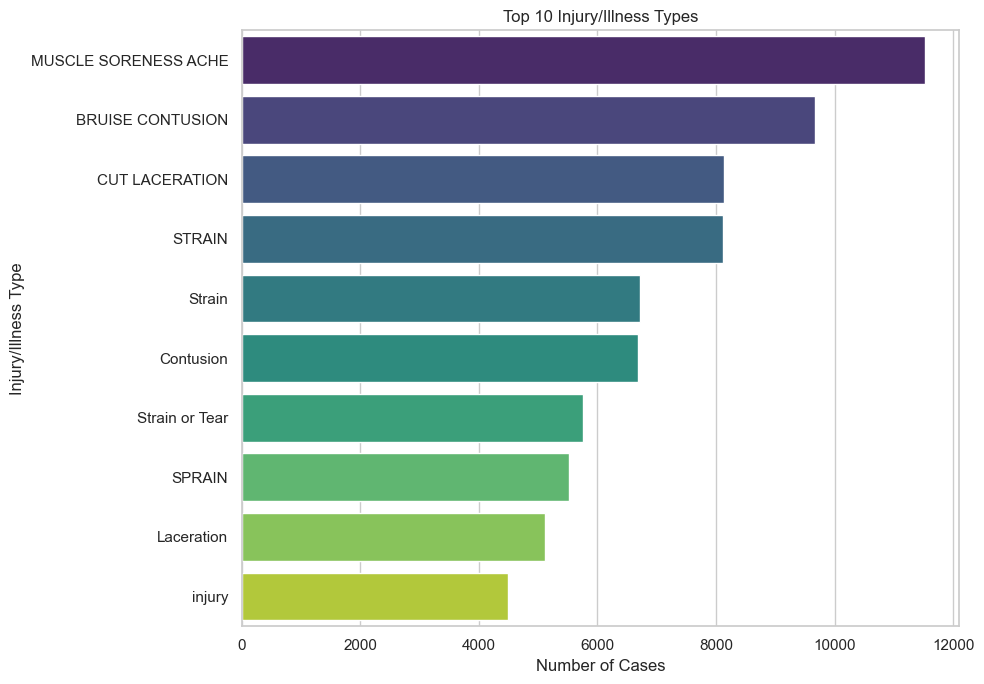

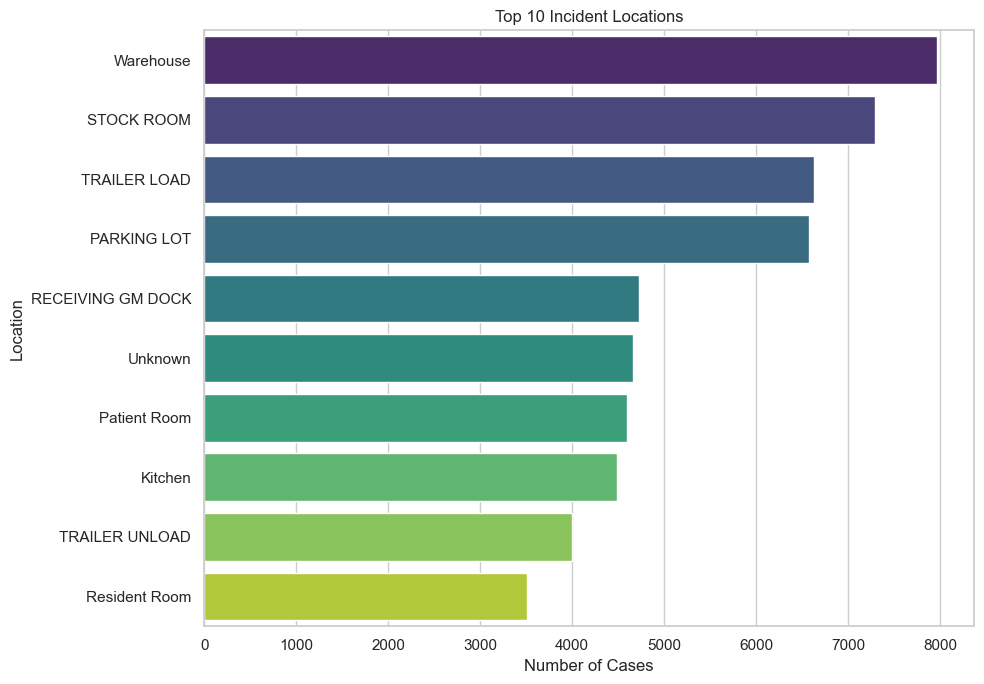

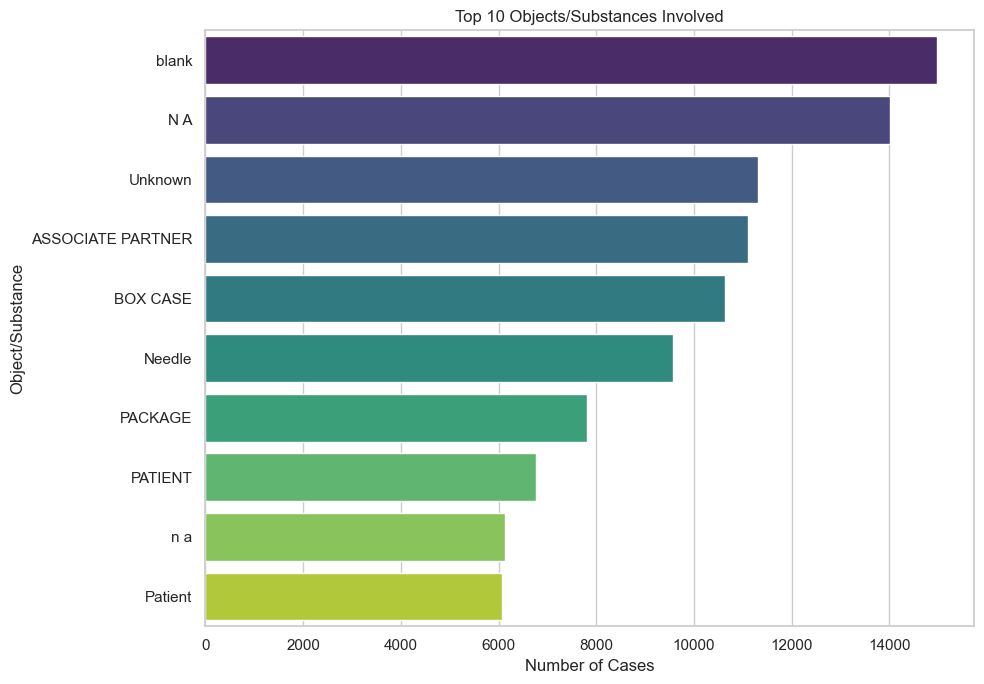

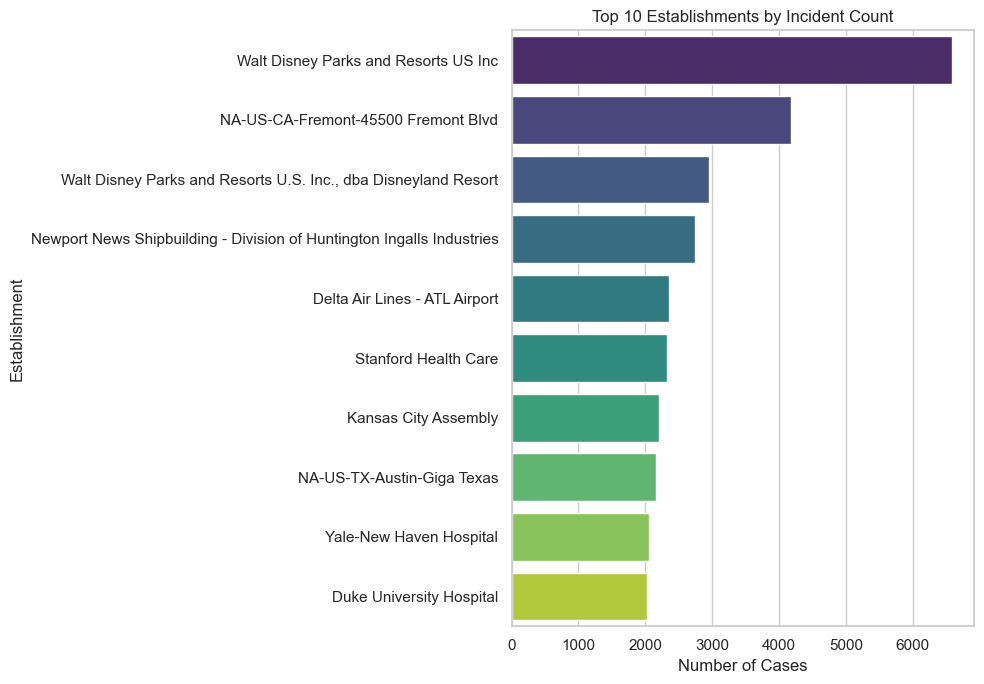

In [40]:
top_injury = df['NEW_NAR_INJURY_ILLNESS'].value_counts().nlargest(10)
create_barplot(top_injury, "Top 10 Injury/Illness Types", "Number of Cases", "Injury/Illness Type")

top_location = df['NEW_INCIDENT_LOCATION'].value_counts().nlargest(10)
create_barplot(top_location, "Top 10 Incident Locations", "Number of Cases", "Location")

top_object = df['NEW_NAR_OBJECT_SUBSTANCE'].value_counts().nlargest(10)
create_barplot(top_object, "Top 10 Objects/Substances Involved", "Number of Cases", "Object/Substance")

top_establishment = df['establishment_name'].value_counts().nlargest(10)
create_barplot(top_establishment, "Top 10 Establishments by Incident Count", "Number of Cases", "Establishment")

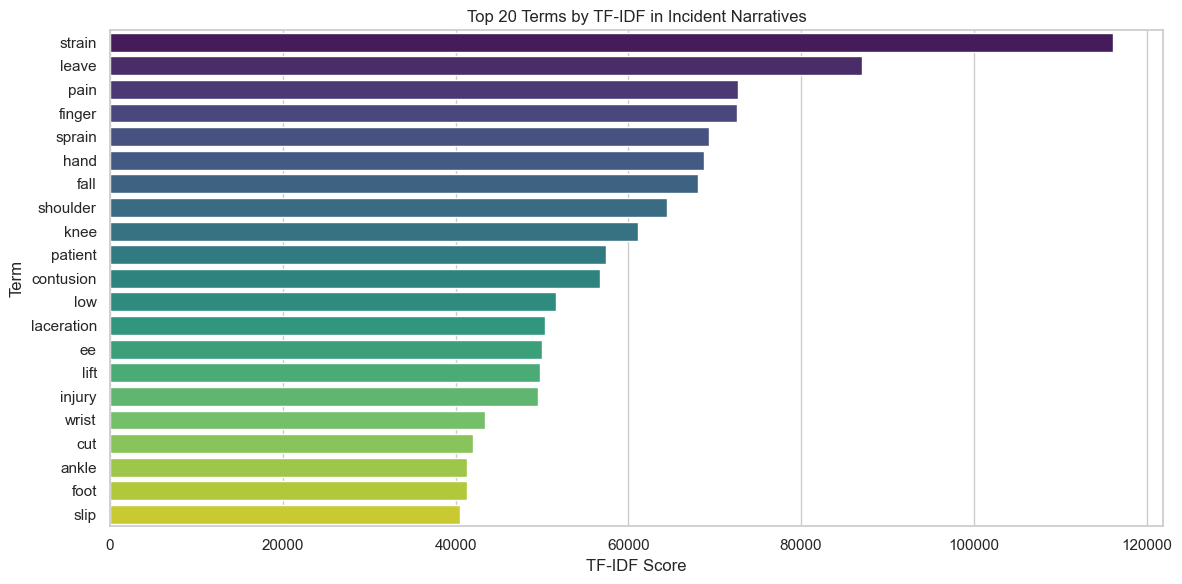

In [41]:
exclude_terms = ['employee', 'right', 'left', 'result', 'redact']
filtered_terms = top_terms_ita[~top_terms_ita['term'].str.contains('|'.join(exclude_terms), case=False, na=False)]

plt.figure(figsize=(12, 6))
sns.barplot(x='tfidf', y='term', data=filtered_terms, hue='term', palette='viridis', legend=False)
plt.title('Top 20 Terms by TF-IDF in Incident Narratives')
plt.xlabel('TF-IDF Score')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

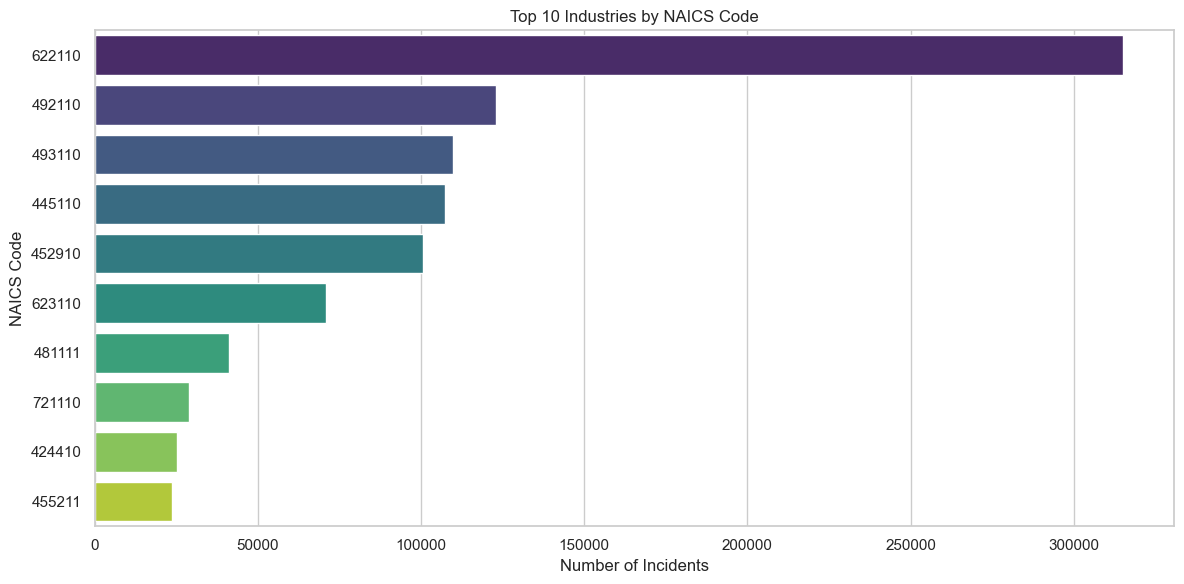

In [42]:
top_naics = df['naics_code'].value_counts().nlargest(10).to_frame().reset_index()
top_naics['naics_code'] = top_naics['naics_code'].astype(int).astype(str)

plt.figure(figsize=(12, 6))
sns.barplot(x='count', y='naics_code', data=top_naics, hue='naics_code', palette='viridis', legend=False)
plt.title('Top 10 Industries by NAICS Code')
plt.xlabel('Number of Incidents')
plt.ylabel('NAICS Code')
plt.tight_layout()
plt.show()

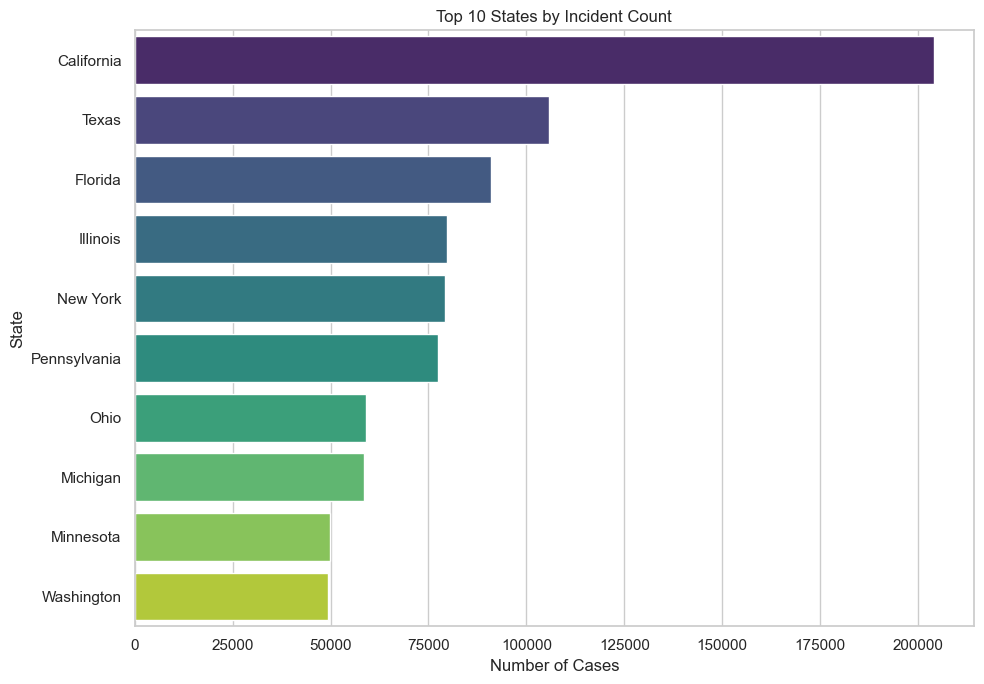

In [43]:
state_map = {
    "AL": "Alabama", "AK": "Alaska", "AZ": "Arizona", "AR": "Arkansas",
    "CA": "California", "CO": "Colorado", "CT": "Connecticut", "DE": "Delaware",
    "FL": "Florida", "GA": "Georgia", "HI": "Hawaii", "ID": "Idaho",
    "IL": "Illinois", "IN": "Indiana", "IA": "Iowa", "KS": "Kansas",
    "KY": "Kentucky", "LA": "Louisiana", "ME": "Maine", "MD": "Maryland",
    "MA": "Massachusetts", "MI": "Michigan", "MN": "Minnesota",
    "MS": "Mississippi", "MO": "Missouri", "MT": "Montana", "NE": "Nebraska",
    "NV": "Nevada", "NH": "New Hampshire", "NJ": "New Jersey",
    "NM": "New Mexico", "NY": "New York", "NC": "North Carolina",
    "ND": "North Dakota", "OH": "Ohio", "OK": "Oklahoma", "OR": "Oregon",
    "PA": "Pennsylvania", "RI": "Rhode Island", "SC": "South Carolina",
    "SD": "South Dakota", "TN": "Tennessee", "TX": "Texas", "UT": "Utah",
    "VT": "Vermont", "VA": "Virginia", "WA": "Washington",
    "WV": "West Virginia", "WI": "Wisconsin", "WY": "Wyoming",
    "DC": "District of Columbia",
}

# Convert two-letter state abbreviations into full names for a cleaner plot.
top_states = df['state'].value_counts().nlargest(10)
top_states.index = top_states.index.map(state_map)
create_barplot(top_states, "Top 10 States by Incident Count", "Number of Cases", "State")

In [45]:
summary = f"""
ITA ANALYSIS SUMMARY

Total incidents: {len(df):,}
Unique establishments: {df['establishment_name'].nunique():,}
Unique companies: {df['company_name'].nunique():,}
Unique NAICS codes: {df['naics_code'].nunique():,}

Top 10 Injury/Illness Types:
{top_injury.to_string() if 'NEW_NAR_INJURY_ILLNESS' in df.columns else 'Not available'}

Top 10 Incident Locations:
{top_location.to_string() if 'NEW_INCIDENT_LOCATION' in df.columns else 'Not available'}

Top 10 Objects/Substances:
{top_object.to_string() if 'NEW_NAR_OBJECT_SUBSTANCE' in df.columns else 'Not available'}

Note: This dataset does not contain:
- Date/time information for temporal analysis
- Severity outcome indicators (hospitalization, amputation, etc.)
- Standardized categorical fields (NatureTitle, EventTitle, Part of Body Title, SourceTitle)
"""

print(summary)


ITA ANALYSIS SUMMARY

Total incidents: 1,642,511
Unique establishments: 115,821
Unique companies: 47,938
Unique NAICS codes: 951

Top 10 Injury/Illness Types:
NEW_NAR_INJURY_ILLNESS
MUSCLE SORENESS ACHE    11522
BRUISE CONTUSION         9675
CUT LACERATION           8132
STRAIN                   8126
Strain                   6711
Contusion                6681
Strain or Tear           5764
SPRAIN                   5513
Laceration               5119
injury                   4492

Top 10 Incident Locations:
NEW_INCIDENT_LOCATION
Warehouse            7970
STOCK ROOM           7292
TRAILER LOAD         6631
PARKING LOT          6573
RECEIVING GM DOCK    4727
Unknown              4661
Patient Room         4595
Kitchen              4483
TRAILER UNLOAD       3995
Resident Room        3513

Top 10 Objects/Substances:
NEW_NAR_OBJECT_SUBSTANCE
blank                14982
N A                  14016
Unknown              11303
ASSOCIATE PARTNER    11116
BOX CASE             10637
Needle             

## TX Institutional Medical Billing Services (SV2)

This section prepares the Texas SV2 billing-line data, derives service-time fields, standardizes key numeric measures, and summarizes utilization and payment patterns.

In [46]:
# Start SV2 processing from a fresh copy of the raw billing data.
df = df_sv2_raw.copy()

In [ ]:
# Parse billing/service dates, derive time fields, and standardize core numeric columns.
for col in ["Bill Selection Date", "Service Line From Date", "Service Line To Date"]:
    df[col] = pd.to_datetime(df[col], errors="ignore")

df["bill_date"] = pd.to_datetime(df["Bill Selection Date"], errors="coerce")
df["service_from_date"] = pd.to_datetime(df["Service Line From Date"], errors="coerce")
df["service_to_date"] = pd.to_datetime(df["Service Line To Date"], errors="coerce")

df["year"] = df["service_from_date"].dt.year
df["month"] = df["service_from_date"].dt.month
df['dayofweek'] = df['Bill Selection Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['dayname'] = df['Bill Selection Date'].dt.day_name()

df = df[(df["service_from_date"].dt.year >= START_YEAR) &
        (df["service_from_date"].dt.year <= END_YEAR)]

for col in ["Total Charge Per Line", "Total Amount Paid Per Line",
            "Days/Units Billed", "Service Adjustment Amount 1"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Create shorter aliases for frequently reused billing measures.
df["charge"] = df["Total Charge Per Line"]
df["paid"] = df["Total Amount Paid Per Line"]
df["units"] = df["Days/Units Billed"]
df["adjustment_amt_1"] = df["Service Adjustment Amount 1"]

# payment rate adjustments
df["payment_rate"] = (df["paid"] / df["charge"] * 100).clip(0, 100)
df["had_adjustment"] = df["adjustment_amt_1"].notna().astype(int)

df["procedure_code"] = df["HCPCS Line Procedure Billed Code"]
df["procedure_desc"] = df["Procedure Description"]
df["revenue_code"] = df["Revenue Billed Code"]
df["place_of_service"] = df["Place of Service Line Code"]

/var/folders/9s/sth28l1x4mb61jw17qrj3qq80000gn/T/ipykernel_70250/2874278127.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_datetime(df[col], errors="ignore")
/var/folders/9s/sth28l1x4mb61jw17qrj3qq80000gn/T/ipykernel_70250/2874278127.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_datetime(df[col], errors="ignore")
/var/folders/9s/sth28l1x4mb61jw17qrj3qq80000gn/T/ipykernel_70250/2874278127.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  df[col] = pd.to_datetime(df[col], errors="ignore")


In [48]:
print(df["service_from_date"].min(), "--", df["service_from_date"].max())

2019-02-06 00:00:00 -- 2024-12-31 00:00:00


In [49]:
# Column-wise non-missingness profile for the SV2 file.
def sv2_stats(df: pd.DataFrame) -> pd.Series:
    completeness = {}
    for col in df.columns:
        total = len(df)
        non_null = df[col].notna().sum()
        complete_pct = (non_null / total) * 100
        completeness[col] = round(complete_pct, 1)
    result = pd.Series(completeness).sort_values(ascending=False)
    return result

In [50]:
sv2_stats(df).mean()

np.float64(52.79852941176471)

### Visualizations

Generate descriptive views of billing activity, procedure distributions, modifiers, temporal patterns, and charge-versus-payment behavior.

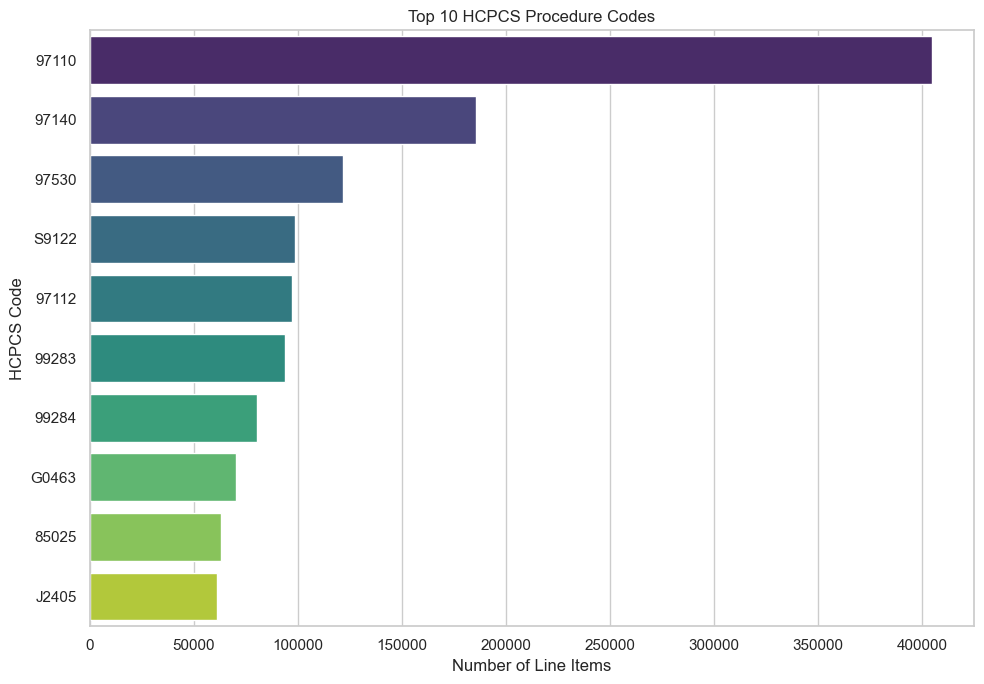

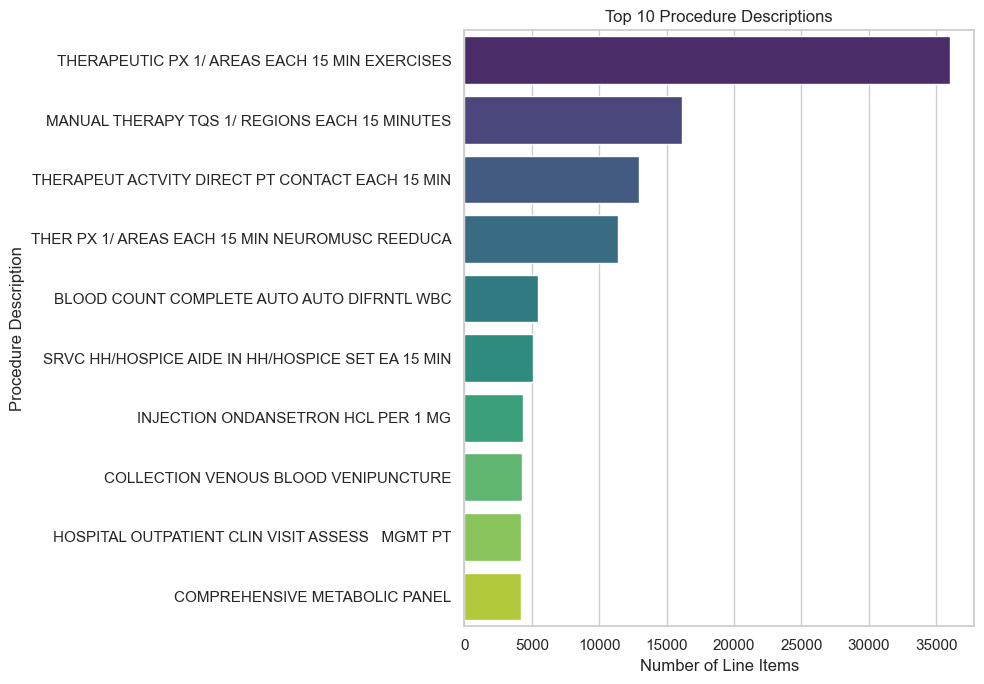

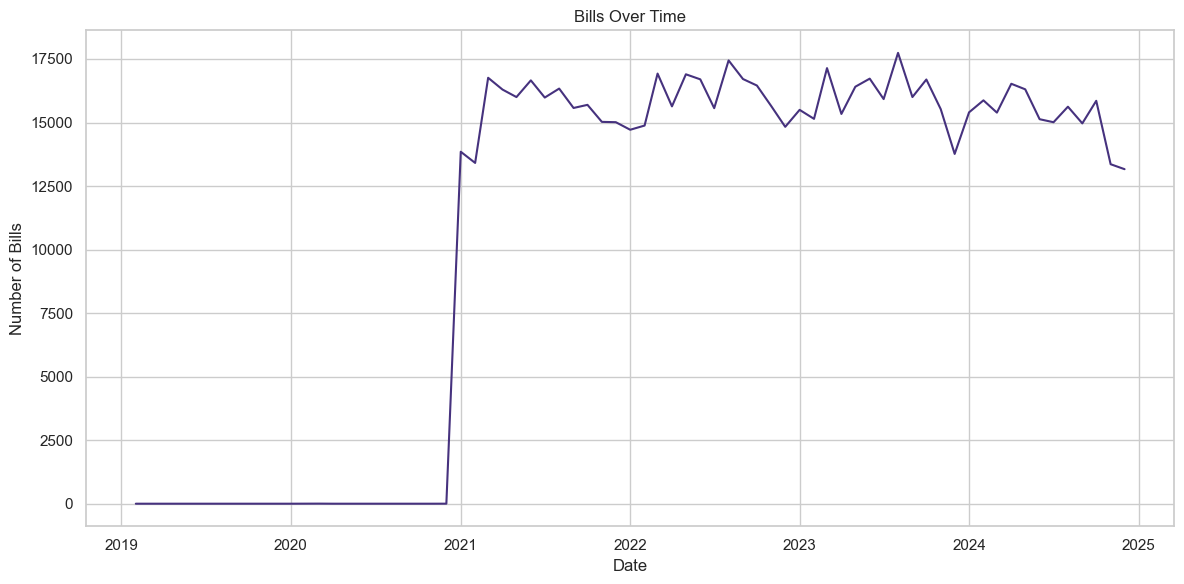

In [51]:
top_procedures = df['HCPCS Line Procedure Billed Code'].value_counts().nlargest(10)
create_barplot(top_procedures, "Top 10 HCPCS Procedure Codes", "Number of Line Items", "HCPCS Code")

top_descriptions = df['Procedure Description'].value_counts().nlargest(10)
create_barplot(top_descriptions, "Top 10 Procedure Descriptions", "Number of Line Items", "Procedure Description")

monthly = (df.groupby(["year", "month"]).agg(bill_count=('Bill ID', 'nunique')).reset_index())
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="date", y="bill_count")
plt.title("Bills Over Time")
plt.ylabel("Number of Bills")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

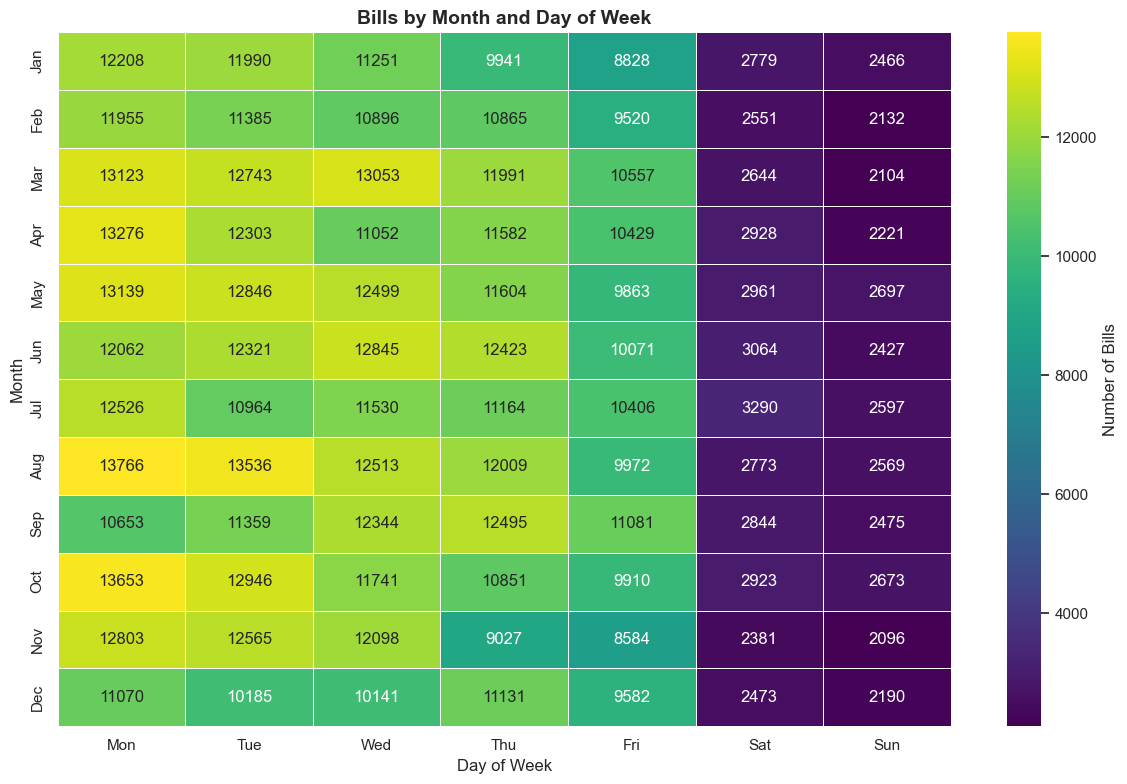

In [52]:
fig, ax = plt.subplots(figsize=(12, 8))

heatmap_data = df.groupby(['month', 'dayofweek'])['Bill ID'].nunique().unstack(fill_value=0)
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
heatmap_data.columns = [day_names[i] for i in heatmap_data.columns]

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.index = [month_names[i-1] for i in heatmap_data.index]

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of Bills'})
ax.set_title('Bills by Month and Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Month', fontsize=12)
plt.tight_layout()
plt.show()

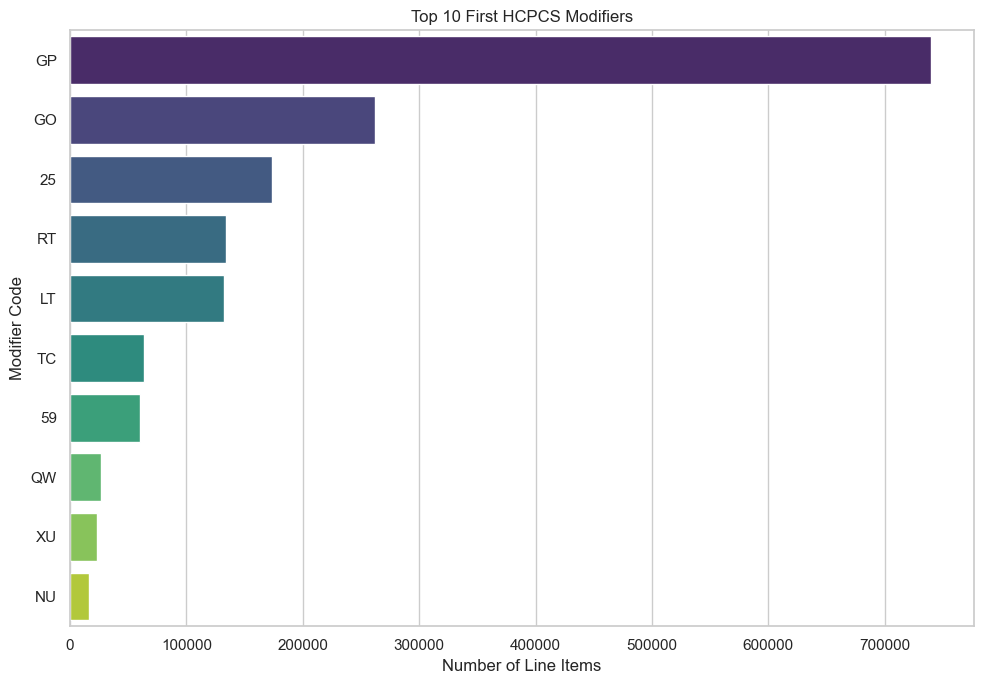

In [53]:
top_modifiers = df['First HCPCS Modifier Billed Code'].value_counts().nlargest(10)
create_barplot(top_modifiers, "Top 10 First HCPCS Modifiers", "Number of Line Items", "Modifier Code")

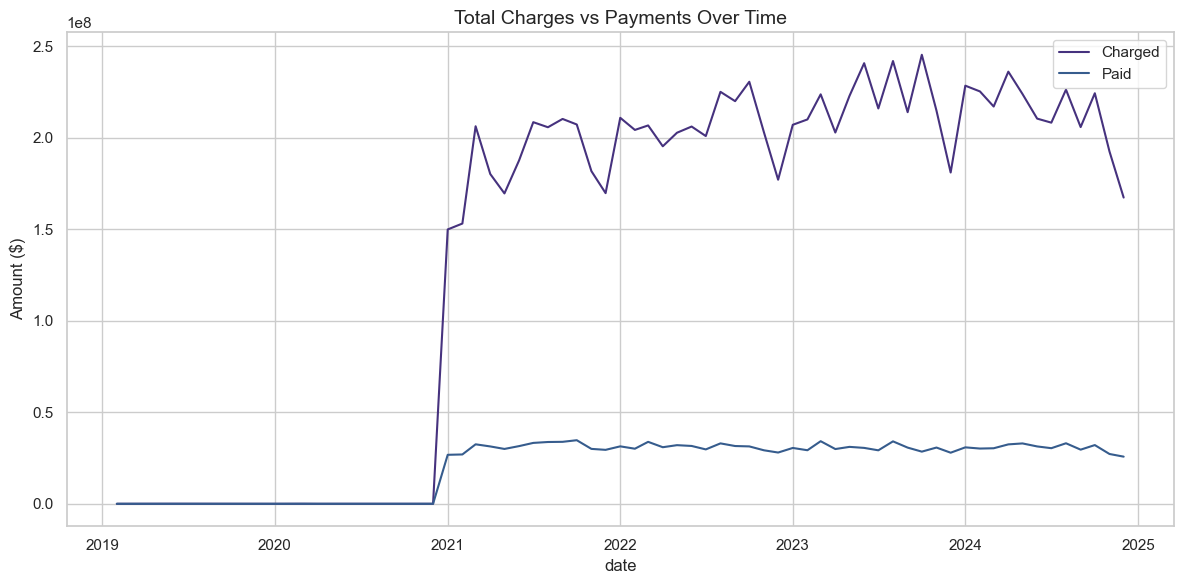

In [54]:
# Aggregate monthly transaction counts and financial measures for temporal trend inspection.
monthly = (df.groupby(["year", "month"]).agg(
    transaction_count=("Bill Detail ID", "count"),
    total_charges=("charge", "sum"),
    total_paid=("paid", "sum"),
    avg_charge=("charge", "mean"),
    ).reset_index()
    )
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="date", y="total_charges", label="Charged")
sns.lineplot(data=monthly, x="date", y="total_paid", label="Paid")
plt.title("Total Charges vs Payments Over Time", fontsize=14)
plt.ylabel("Amount ($)")
plt.tight_layout()
plt.show()

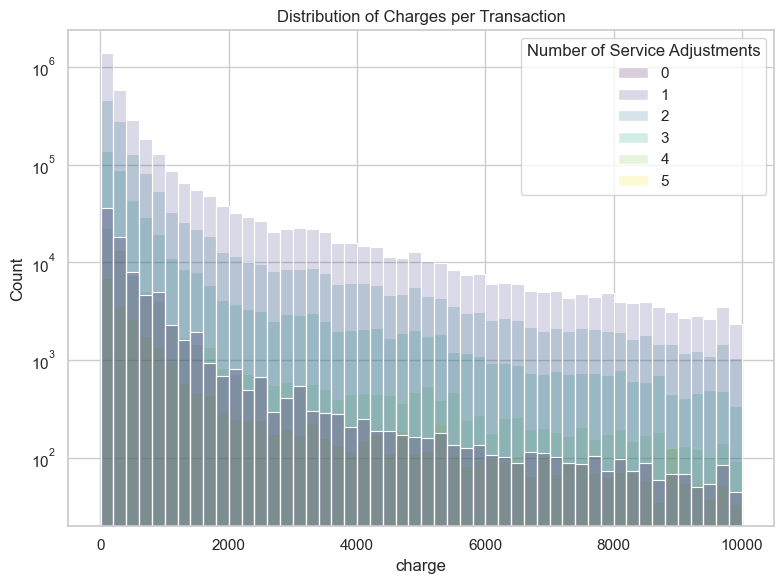

In [55]:
charges_clean = df[df["charge"].between(1, 10000)]

plt.figure(figsize=(8, 6))
sns.histplot(data=charges_clean, x="charge", hue="Number of Service Adjustments", palette="viridis", bins=50, alpha=0.2)
plt.yscale("log")
plt.title("Distribution of Charges per Transaction")
plt.tight_layout()
plt.show()

In [56]:
print(df["charge"].max())

1396967.0


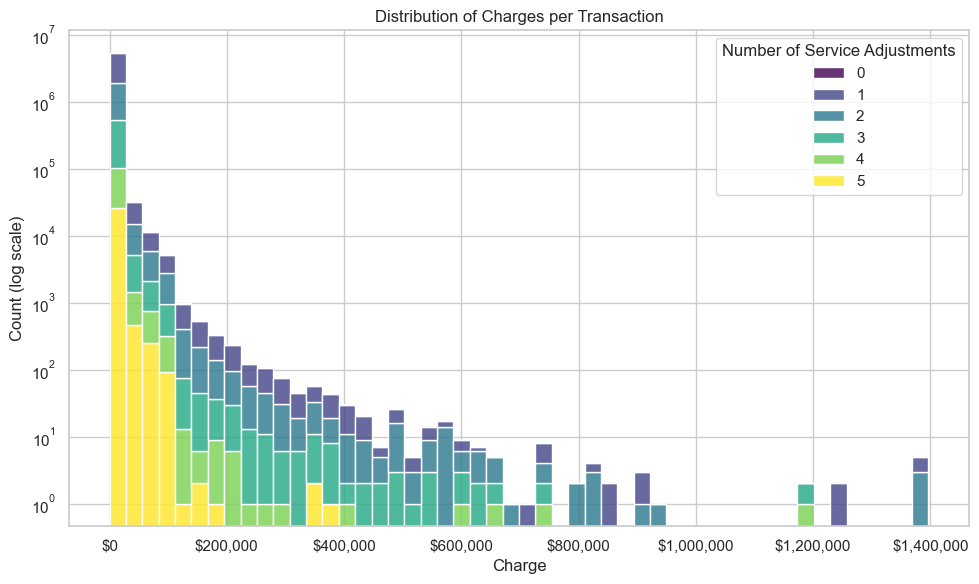

In [57]:
#charges_clean = df[df["charge"].between(1, 10000)]
charges_clean = df[(df["charge"].notna()) & (df["charge"] > 0)]

plt.figure(figsize=(10, 6))
sns.histplot(
    data=charges_clean, 
    x="charge", 
    hue="Number of Service Adjustments", 
    palette="viridis", 
    bins=50, 
    multiple="stack",  # Stack instead of overlay
    alpha=0.8,
    edgecolor=None
)
plt.yscale("log")
plt.title("Distribution of Charges per Transaction")
plt.xlabel("Charge")
plt.ylabel("Count (log scale)")
ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

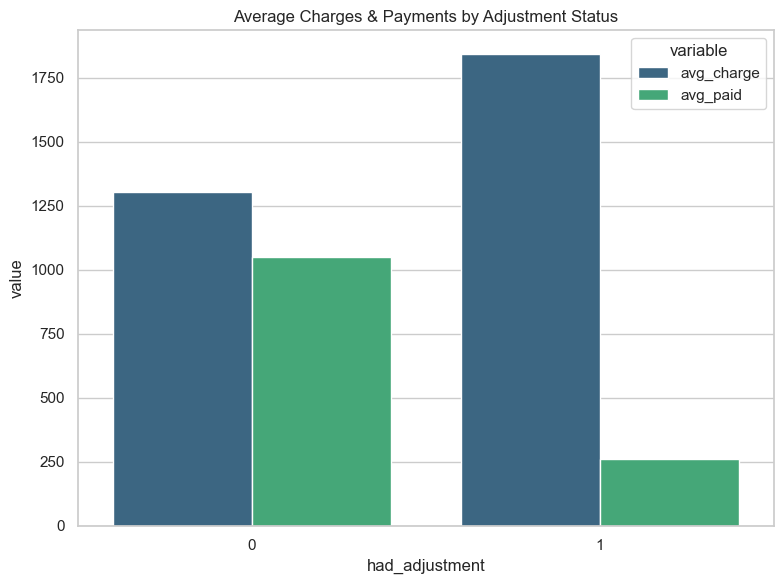

In [58]:
adj_summary = (df.groupby("had_adjustment").agg(avg_charge=("charge", "mean"), avg_paid=("paid", "mean")).reset_index())

plt.figure(figsize=(8, 6))
sns.barplot(data=adj_summary.melt(id_vars="had_adjustment"), x="had_adjustment", y="value", 
            hue="variable", palette="viridis",)
plt.title("Average Charges & Payments by Adjustment Status")
plt.tight_layout()
plt.show()

In [59]:
summary = f"""
SV2 ANALYSIS SUMMARY

Total transactions: {len(df):,}
Unique bills: {df['Bill ID'].nunique():,}
Date range: {df['service_from_date'].min()} to {df['service_from_date'].max()}

Financial Summary:
- Total charges: ${df['charge'].sum():,.2f}
- Total paid: ${df['paid'].sum():,.2f}
- Overall payment rate: {(df['paid'].sum()/df['charge'].sum()*100):.1f}%

Procedure Codes:
- Unique HCPCS codes: {df['procedure_code'].nunique()}

Adjustment Patterns:
- With adjustment: {df['had_adjustment'].sum():,}
"""

print(summary)


SV2 ANALYSIS SUMMARY

Total transactions: 5,401,493
Unique bills: 737,818
Date range: 2019-02-06 00:00:00 to 2024-12-31 00:00:00

Financial Summary:
- Total charges: $9,898,094,222.61
- Total paid: $1,479,861,510.16
- Overall payment rate: 15.0%

Procedure Codes:
- Unique HCPCS codes: 5788

Adjustment Patterns:
- With adjustment: 5,308,244



## Oregon Workers’ Compensation Record Level Claims (OR_WC)

This section processes the Oregon workers’ compensation claims file, converts quarter-based injury dates into analytic timestamps, and summarizes claim characteristics and temporal patterns.

In [60]:
# Start Oregon claims processing from a fresh copy of the raw data.
df = df_or_wc_raw.copy()

In [61]:
# Convert quarter-coded dates into timestamps for temporal analysis.
def parse_quarterly_date(quarter_str):
    if pd.isna(quarter_str):
        return pd.NaT
    try:
        year = int(str(quarter_str)[:4])
        quarter = int(str(quarter_str)[-1])
        month = quarter * 3
        return pd.Timestamp(year=year, month=month, day=1)
    except (ValueError, TypeError) as exc:
        print(exc)
        return pd.NaT

df['InjuryDate'] = df['Date of Injury'].apply(parse_quarterly_date)
df['Year'] = df['InjuryDate'].dt.year
df['Month'] = df['InjuryDate'].dt.month
df['Quarter'] = df['Date of Injury'].str[-2:]  #extract Q1, Q2, Q3, Q4

df = df[(df["InjuryDate"].dt.year >= START_YEAR) &
        (df["InjuryDate"].dt.year <= END_YEAR)]

In [62]:
print(df["InjuryDate"].min(), "--", df["InjuryDate"].max())

2015-03-01 00:00:00 -- 2022-12-01 00:00:00


In [63]:
# Basic Oregon completeness summary for selected analytic fields.
def or_wc_stats(df):
    total = len(df)
    missing_naics = df['NAICS Code'].isna().mean() * 100
    missing_injury = df['Nature of Injury Code'].isna().mean() * 100
    completeness = 100 - (missing_naics + missing_injury)
    return total, missing_naics, missing_injury, completeness

In [64]:
or_wc_stats(df)

(170525, np.float64(0.0), np.float64(0.0), np.float64(100.0))

### Visualizations

Generate descriptive plots for injury nature, body part, event, occupation, industry, and claim volume over time.

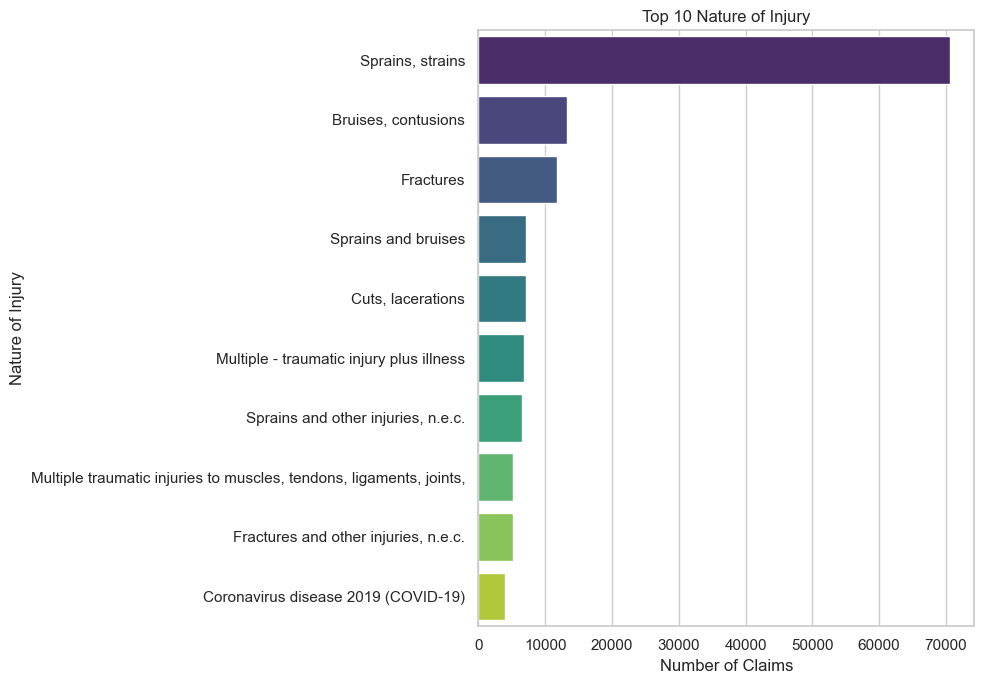

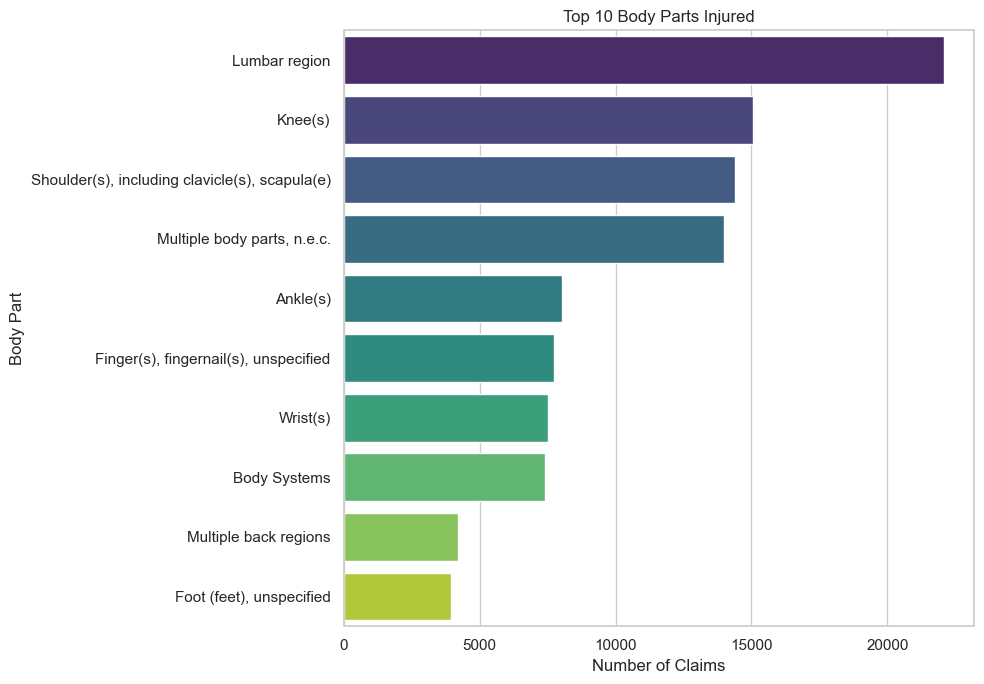

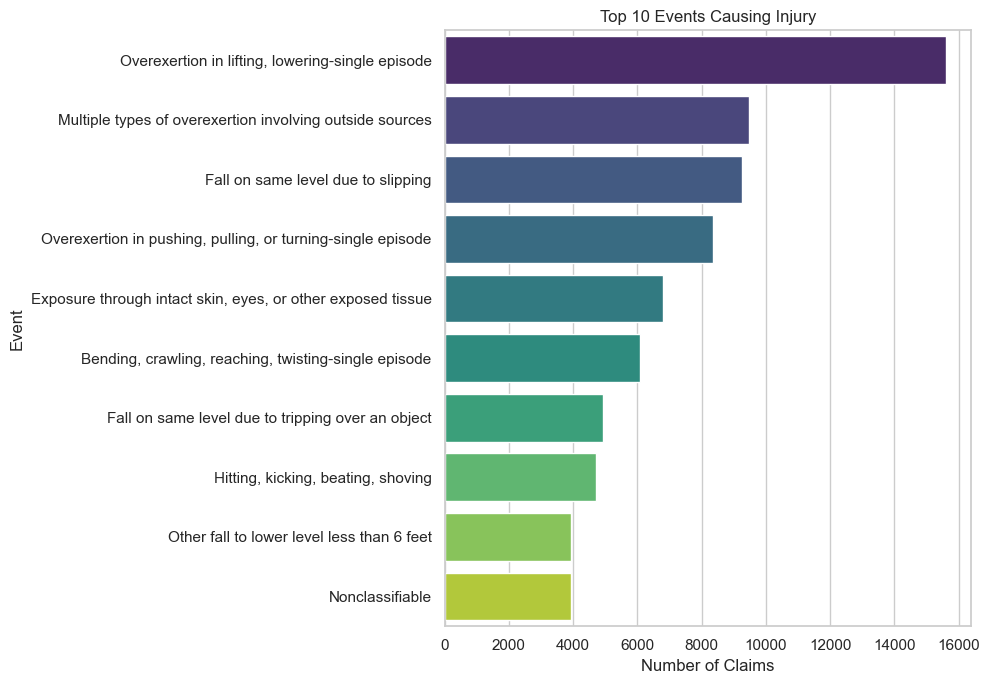

In [65]:
top_nature = df['Nature of Injury (Description)'].value_counts().nlargest(10)
create_barplot(top_nature, "Top 10 Nature of Injury", "Number of Claims", "Nature of Injury")

top_body = df['Body Part Injured (Description)'].value_counts().nlargest(10)
create_barplot(top_body, "Top 10 Body Parts Injured", "Number of Claims", "Body Part")

top_event = df['Event of Injury (Description)'].value_counts().nlargest(10)
create_barplot(top_event, "Top 10 Events Causing Injury", "Number of Claims", "Event")

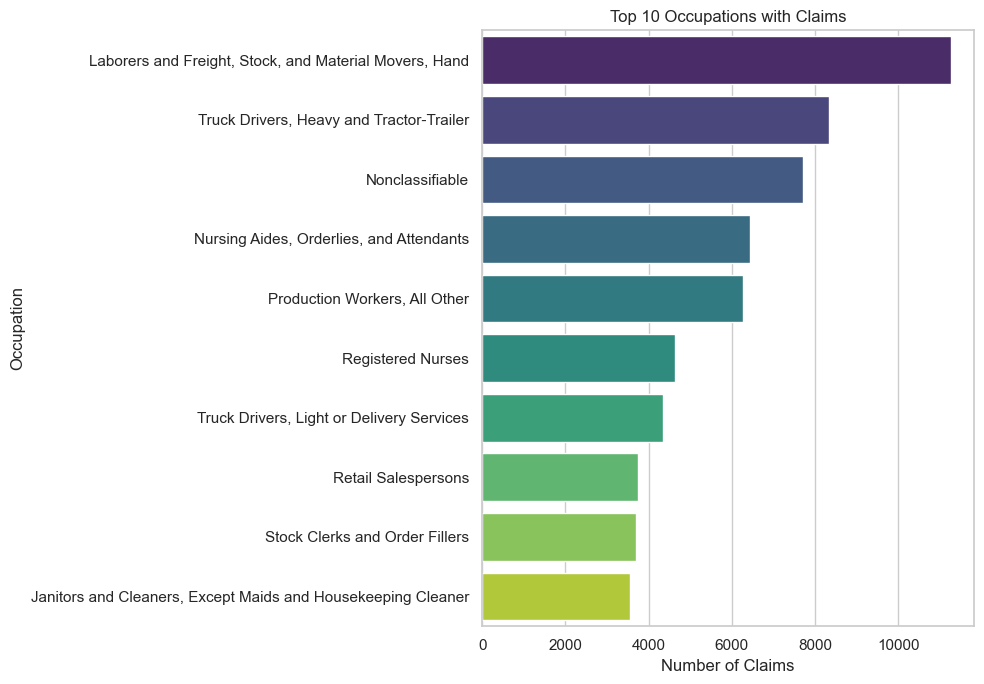

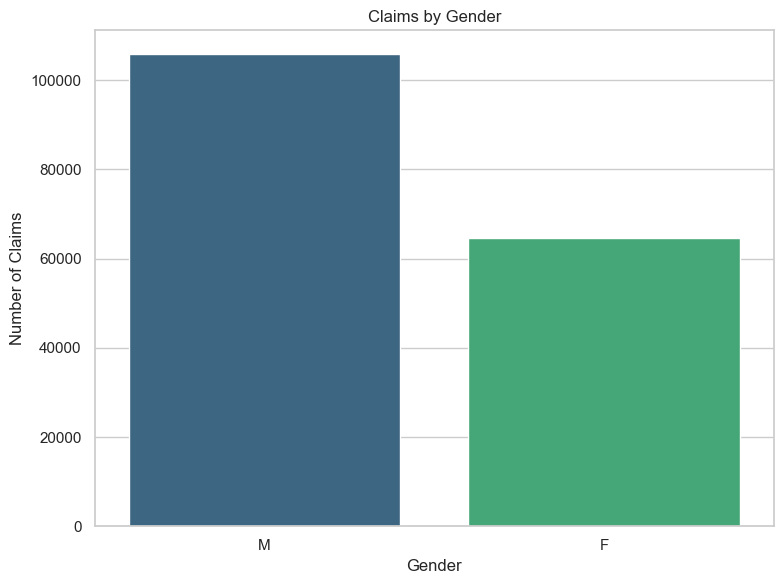

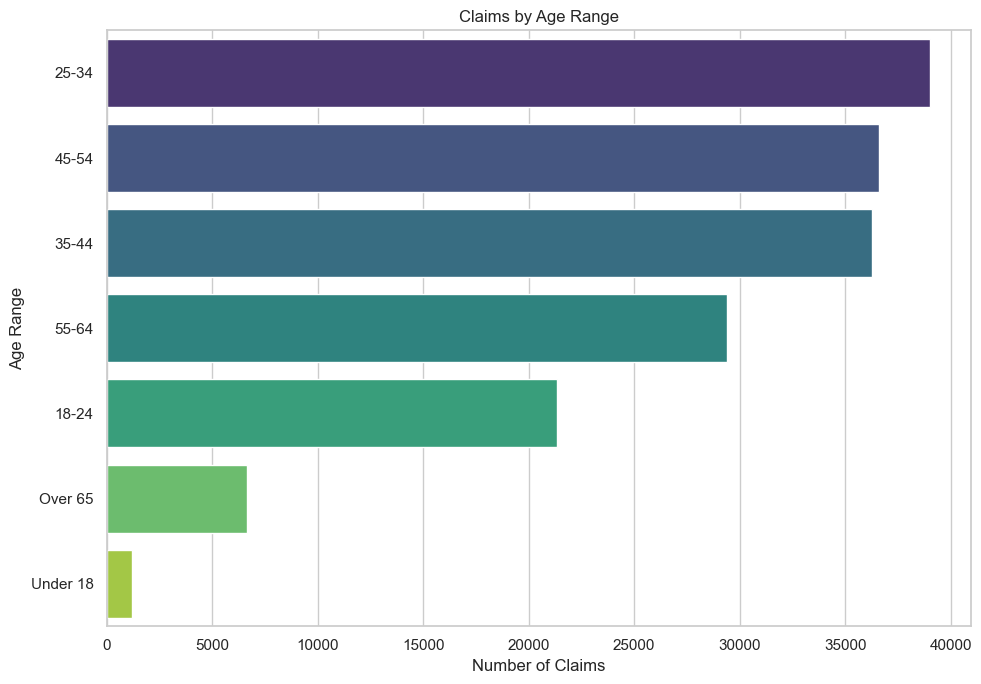

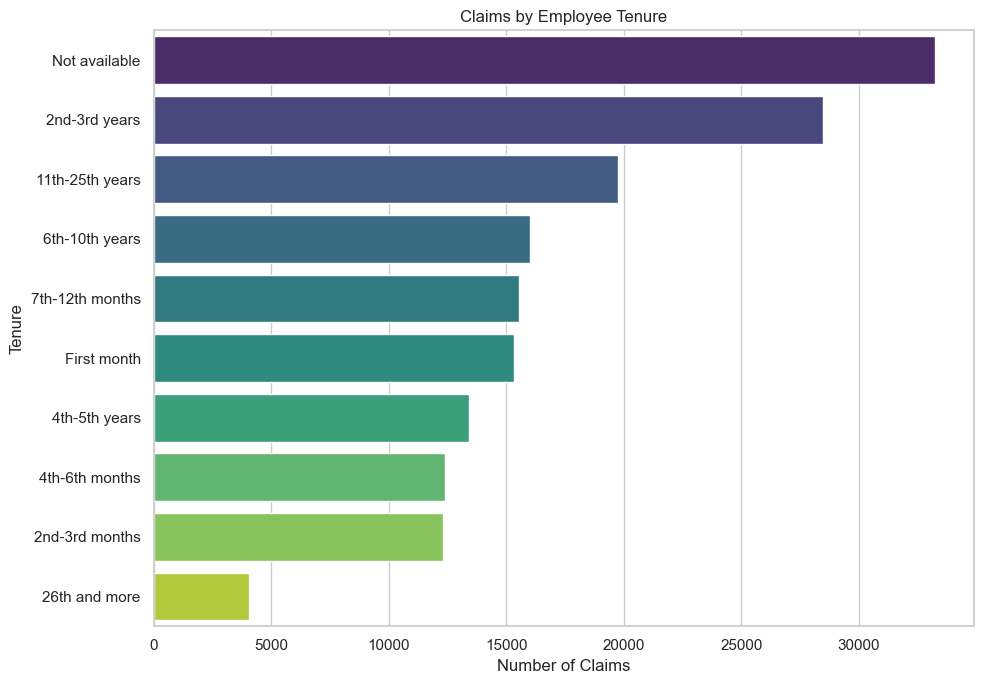

In [66]:
top_occupation = df['Occupation Description'].value_counts().nlargest(10)
create_barplot(top_occupation, "Top 10 Occupations with Claims", "Number of Claims", "Occupation")

gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index, 
            palette='viridis', legend=False)
plt.title("Claims by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()

age_counts = df['Age Range'].value_counts()
create_barplot(age_counts, "Claims by Age Range", "Number of Claims", "Age Range")

tenure_counts = df['Tenure'].value_counts()
create_barplot(tenure_counts, "Claims by Employee Tenure", "Number of Claims", "Tenure")

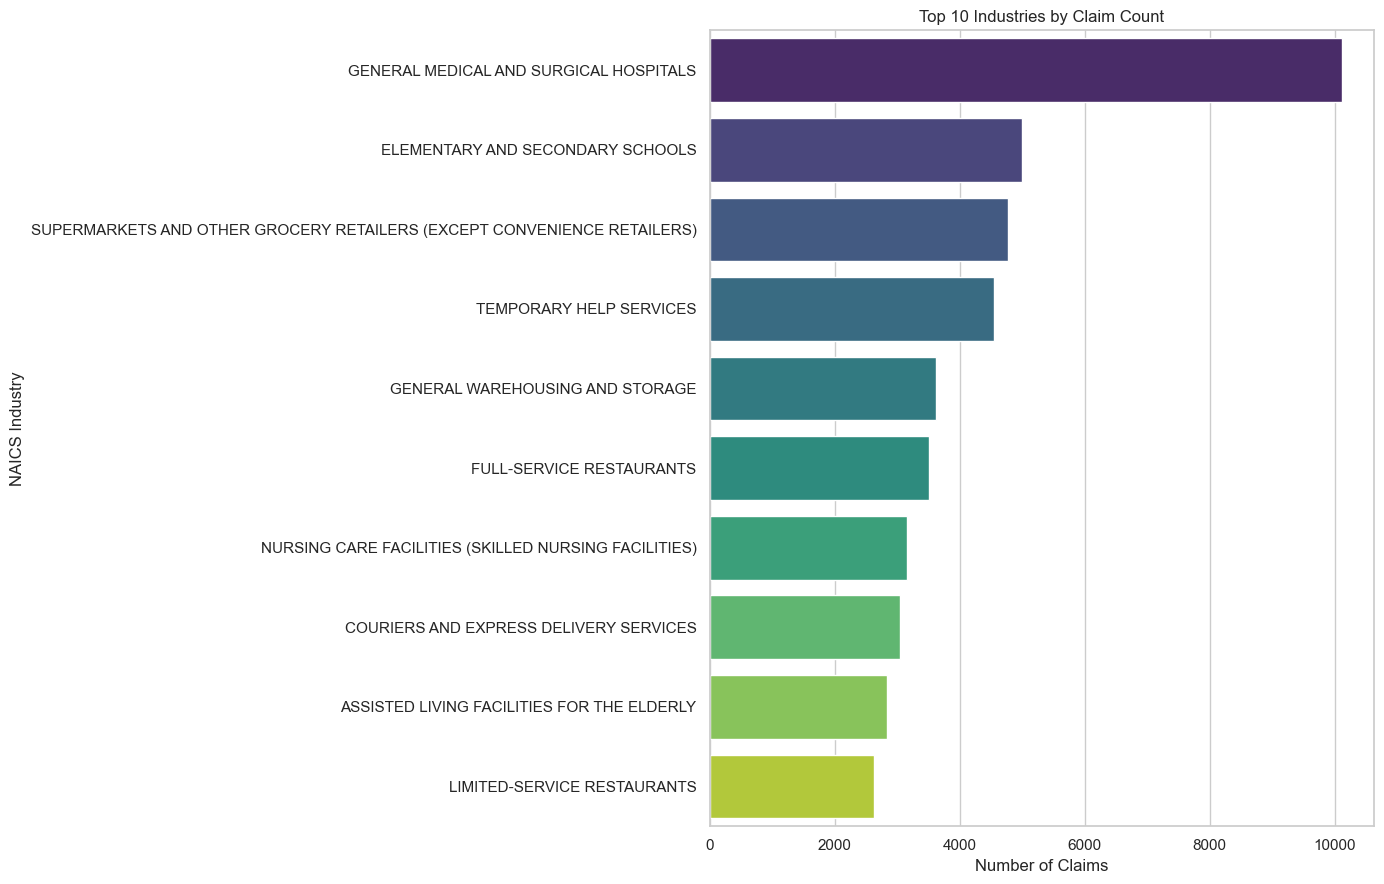

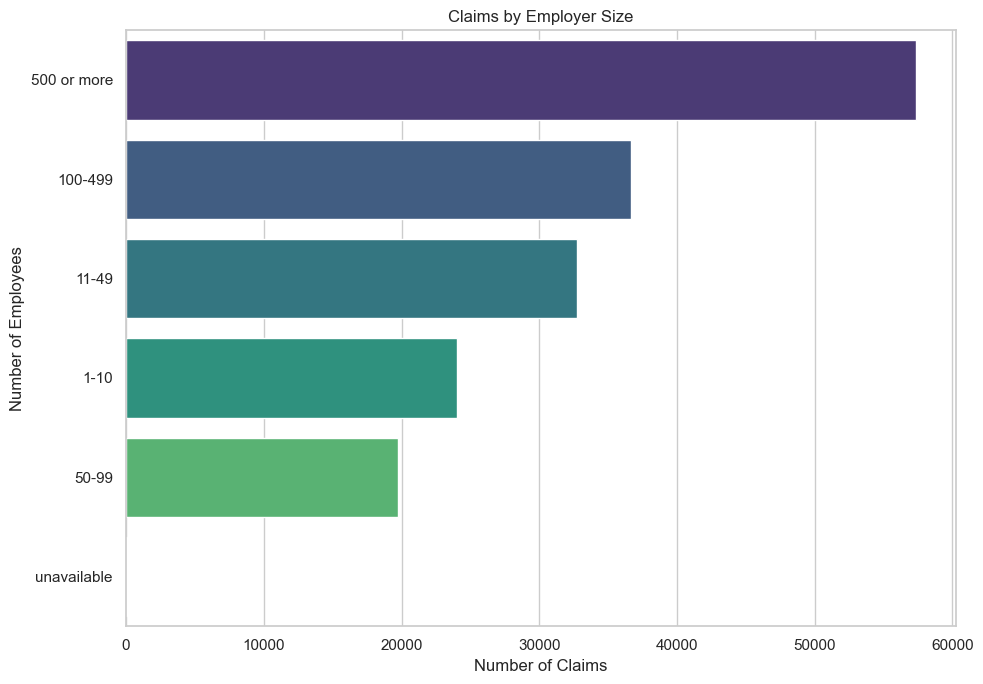

In [67]:
top_naics = df['NAICS Code (Description)'].value_counts().nlargest(10)
create_barplot(top_naics, "Top 10 Industries by Claim Count", "Number of Claims", "NAICS Industry", figsize=(14, 9))

size_counts = df['Number of employees'].value_counts()
create_barplot(size_counts, "Claims by Employer Size", "Number of Claims", "Number of Employees")

/var/folders/9s/sth28l1x4mb61jw17qrj3qq80000gn/T/ipykernel_70250/3749180609.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_temp['Date of Injury'] = pd.to_datetime(df_temp['Date of Injury'], errors="coerce")


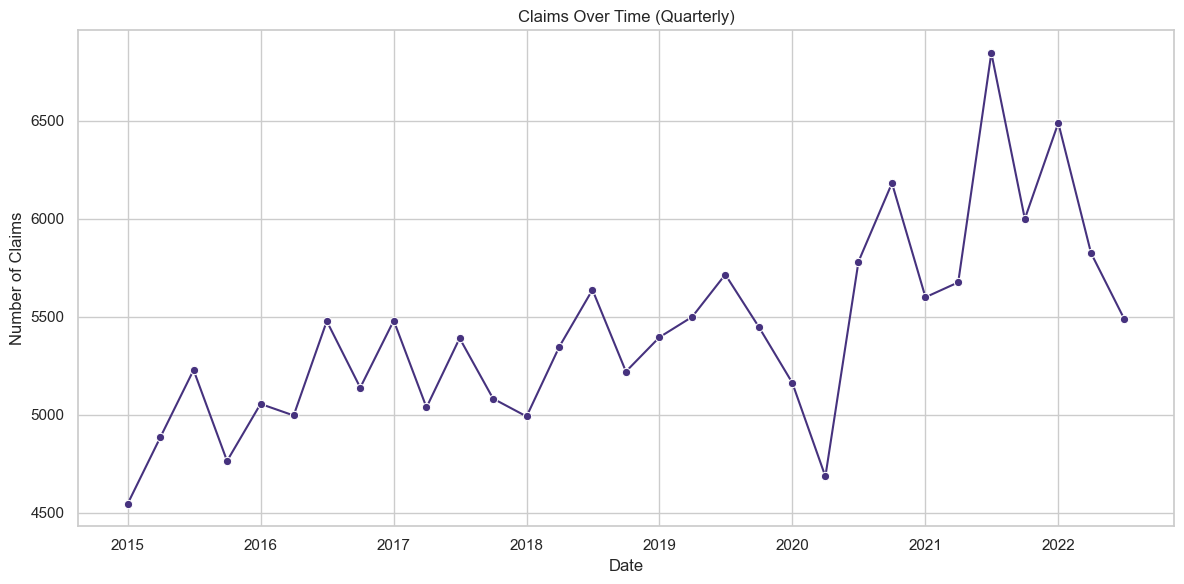

In [68]:
# Use a temporary copy for plotting so the main dataframe remains unchanged for later cells.
df_temp = df.copy()
df_temp['Date of Injury'] = pd.to_datetime(df_temp['Date of Injury'], errors="coerce")
df_temp["year"] = df_temp['Date of Injury'].dt.year
df_temp["month"] = df_temp['Date of Injury'].dt.month

monthly = df_temp.groupby(["year", "month"]).size().reset_index(name="claim_count")
monthly["date"] = pd.to_datetime(monthly[["year", "month"]].assign(day=1))
monthly = monthly.iloc[:-1].reset_index(drop=True)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="date", y="claim_count", marker='o')
plt.title("Claims Over Time (Quarterly)")
plt.ylabel("Number of Claims")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

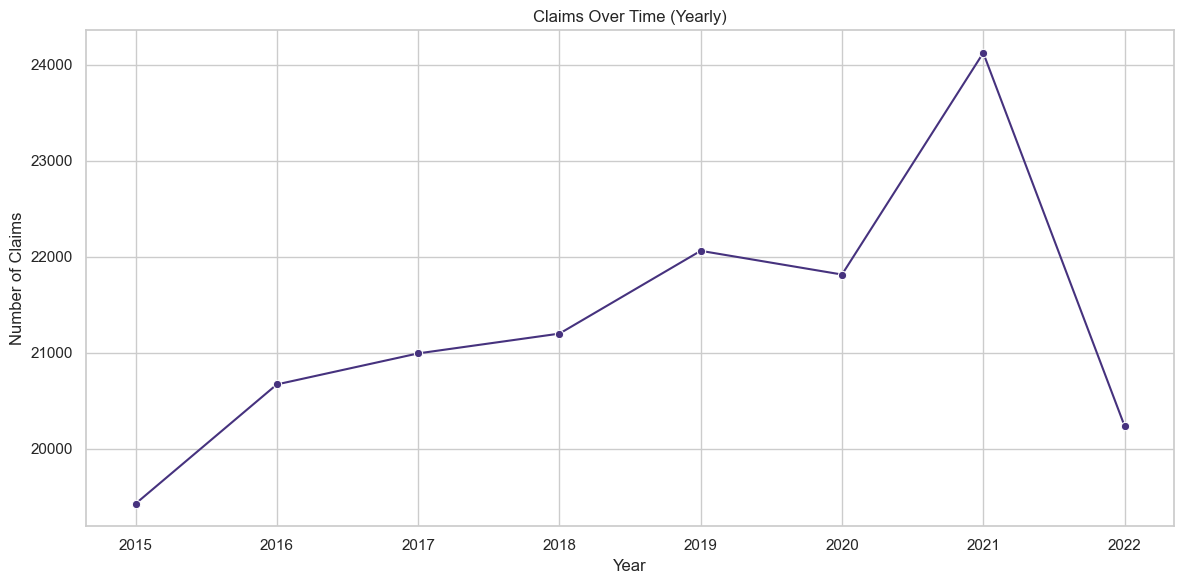

In [69]:
yearly = df.groupby('Year').size().reset_index(name='claim_count')
plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly, x='Year', y='claim_count', marker='o')
plt.title("Claims Over Time (Yearly)")
plt.ylabel("Number of Claims")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

In [70]:
summary = f"""
OR_WC ANALYSIS SUMMARY

Total claims: {len(df):,}
Unique employers: {df['Employer Number'].nunique():,}
Date range: {df['Date of Injury'].min()} to {df['Date of Injury'].max()}
Claim reference years: {df['Claim Reference Year'].min()} to {df['Claim Reference Year'].max()}

Demographics:
- Unique counties: {df['County of Injury'].nunique():,}
- Gender distribution:
{df['Gender'].value_counts().to_string() if 'Gender' in df.columns else 'Not available'}

Top 10 Nature of Injury:
{top_nature.to_string() if ('Nature of Injury (Description)' in df.columns or 'Nature of Injury Code' in df.columns) else 'Not available'}

Top 10 Body Parts Injured:
{top_body.to_string() if ('Body Part Injured (Description)' in df.columns or 'Part of Body Code' in df.columns) else 'Not available'}

Top 10 Occupations:
{top_occupation.to_string() if 'Occupation Description' in df.columns else 'Not available'}

Note: This dataset contains workers compensation claims data with:
- Quarterly date granularity (not daily dates)
- Nature of Injury and Body Part codes/descriptions
- Demographic information (age, gender, tenure)
- Employer and industry information

This dataset does NOT contain:
- Daily date information (only quarterly)
- Event type fields (EventTitle)
- Injury source fields (SourceTitle)
- Severity outcome indicators (hospitalization, amputation, etc.)
- Narrative text fields for natural language processing
"""

print(summary)


OR_WC ANALYSIS SUMMARY

Total claims: 170,525
Unique employers: 28,161
Date range: 2015Q1 to 2022Q4
Claim reference years: 2015 to 2022

Demographics:
- Unique counties: 38
- Gender distribution:
Gender
M    105839
F     64685

Top 10 Nature of Injury:
Nature of Injury (Description)
Sprains, strains                                                       70679
Bruises, contusions                                                    13275
Fractures                                                              11727
Sprains and bruises                                                     7150
Cuts, lacerations                                                       7108
Multiple - traumatic injury plus illness                                6753
Sprains and other injuries, n.e.c.                                      6538
Multiple traumatic injuries to muscles, tendons, ligaments, joints,     5199
Fractures and other injuries, n.e.c.                                    5114
Coronavirus disease 20

## New York State Workers’ Compensation Injury Claims (NY_WC)

This section processes the New York workers’ compensation claims data and summarizes injury coding, demographics, and temporal patterns using the available WCIO and OIICS-related fields.

In [71]:
# Start New York claims processing from a fresh copy of the raw data.
df = df_ny_wc_raw.copy()

In [72]:
# Parse accident dates and derive calendar fields used in later summaries and plots.
df['Accident Date'] = pd.to_datetime(df['Accident Date'], errors="coerce")
df['Year'] = df['Accident Date'].dt.year
df['Month'] = df['Accident Date'].dt.month
df['DayOfWeek'] = df['Accident Date'].dt.dayofweek  # 0=Monday, 6=Sunday
df['DayName'] = df['Accident Date'].dt.day_name()

df = df[(df["Accident Date"].dt.year >= START_YEAR) &
        (df["Accident Date"].dt.year <= END_YEAR)]

print("\nData summary:")
print(f"Date range: {df['Accident Date'].min()} → {df['Accident Date'].max()}")
print(f"Unique claim types: {df['Claim Type'].nunique()}")


Data summary:
Date range: 2015-01-01 00:00:00 → 2016-06-25 00:00:00
Unique claim types: 4


In [73]:
# Basic New York completeness summary for selected analytic fields.
def ny_wc_stats(df):
    total = len(df)
    missing_naics = df['OIICS Nature of Injury Code'].isna().mean() * 100
    missing_injury = df['WCIO Nature of Injury Code'].isna().mean() * 100
    completeness = 100 - (missing_naics + missing_injury)
    return total, missing_naics, missing_injury, completeness

In [74]:
ny_wc_stats(df)

(266686,
 np.float64(99.99962502718553),
 np.float64(3.8914678685795283),
 np.float64(-3.8910928957650555))

### Visualizations

Generate descriptive plots for injury nature, body part, event exposure, injury source, cause of injury, and claim counts over time.

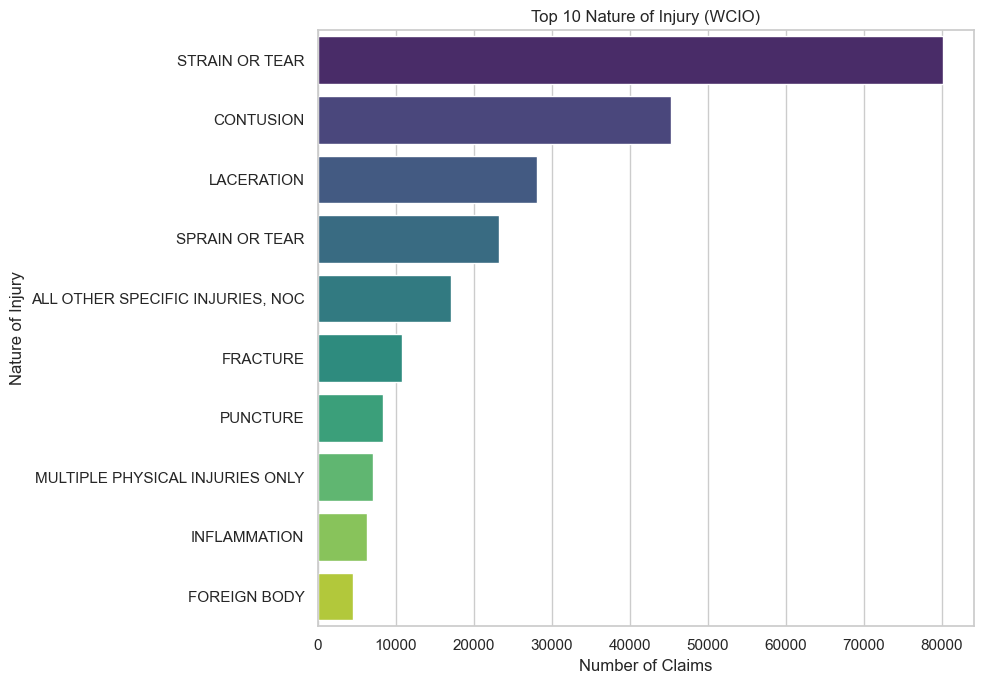

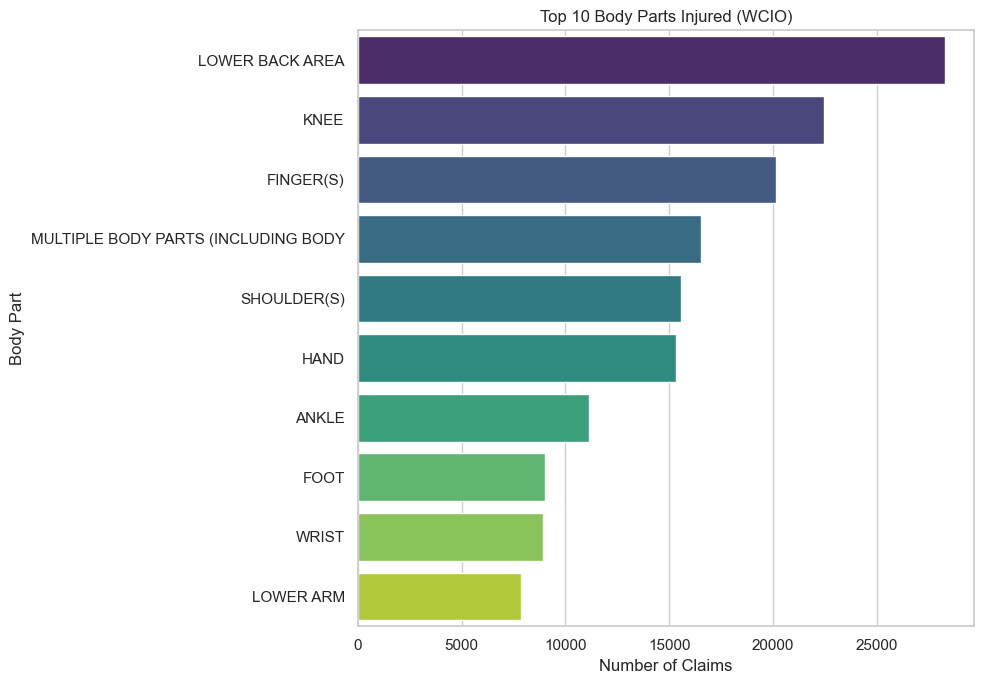

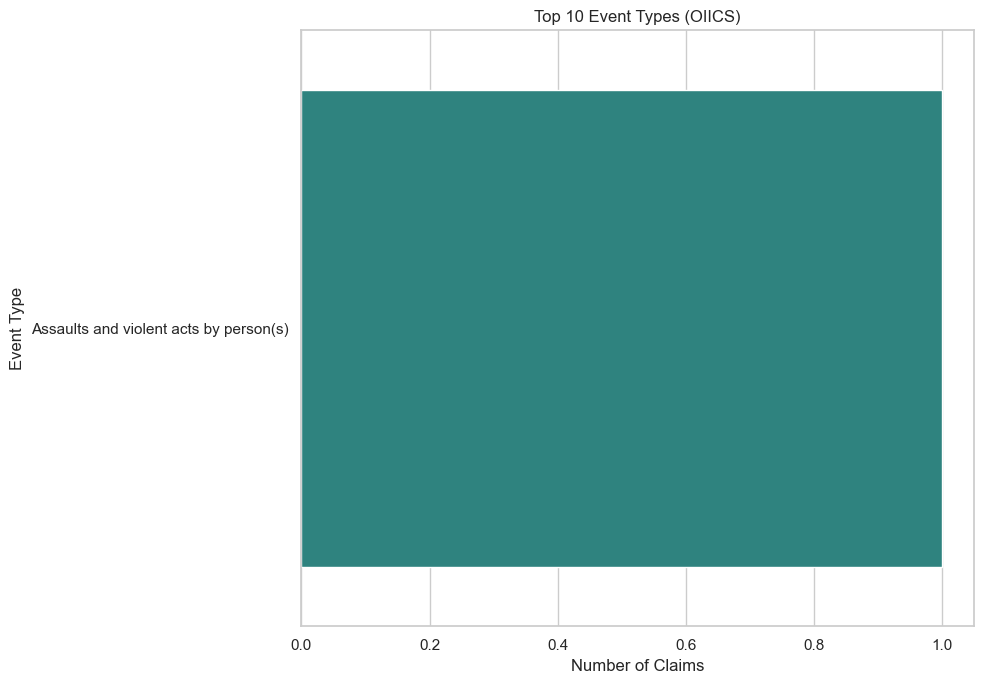

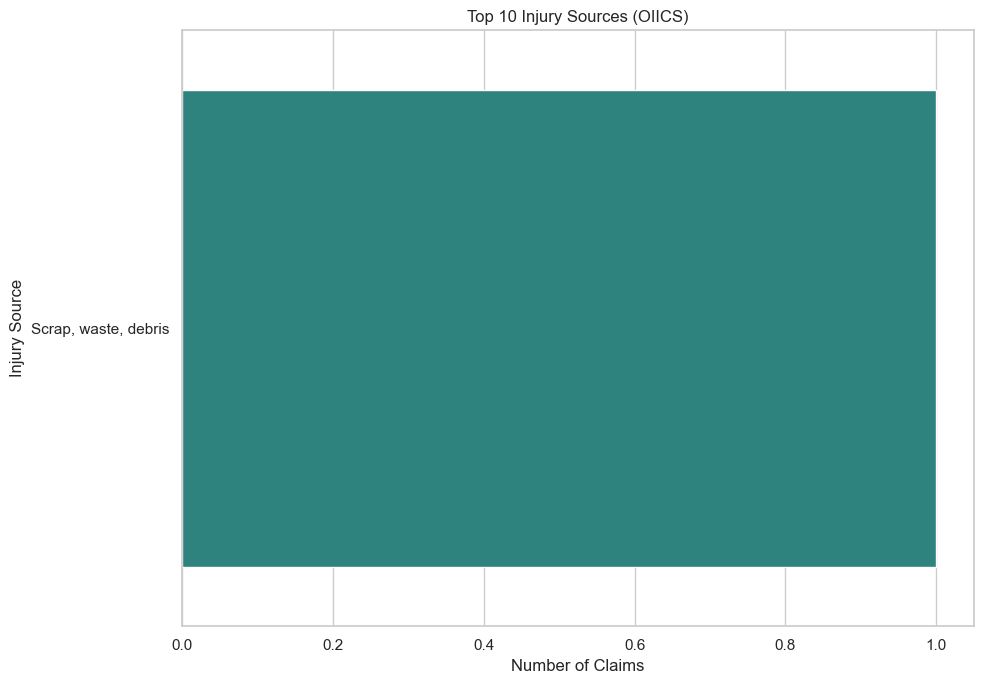

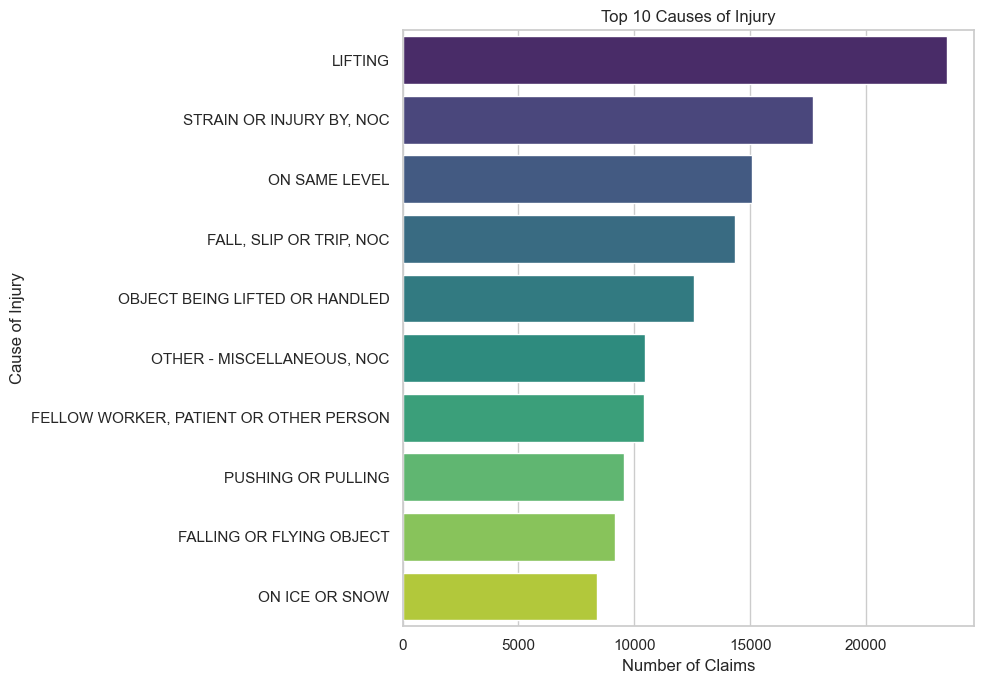

In [75]:
top_nature = df['WCIO Nature of Injury Description'].value_counts().nlargest(10)
create_barplot(top_nature, "Top 10 Nature of Injury (WCIO)", "Number of Claims", "Nature of Injury")

top_body = df['WCIO Part Of Body Description'].value_counts().nlargest(10)
create_barplot(top_body, "Top 10 Body Parts Injured (WCIO)", "Number of Claims", "Body Part")

top_event = df['OIICS Event Exposure Description'].value_counts().nlargest(10)
create_barplot(top_event, "Top 10 Event Types (OIICS)", "Number of Claims", "Event Type")

top_source = df['OIICS Injury Source Description'].value_counts().nlargest(10)
create_barplot(top_source, "Top 10 Injury Sources (OIICS)", "Number of Claims", "Injury Source")

top_cause = df['WCIO Cause of Injury Description'].value_counts().nlargest(10)
create_barplot(top_cause, "Top 10 Causes of Injury", "Number of Claims", "Cause of Injury")

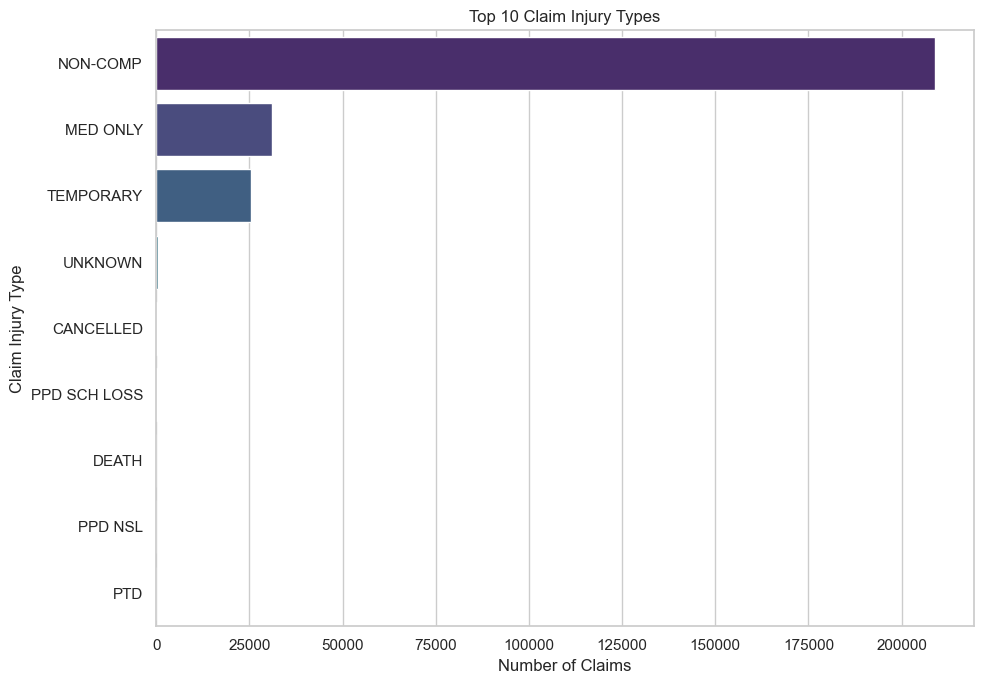

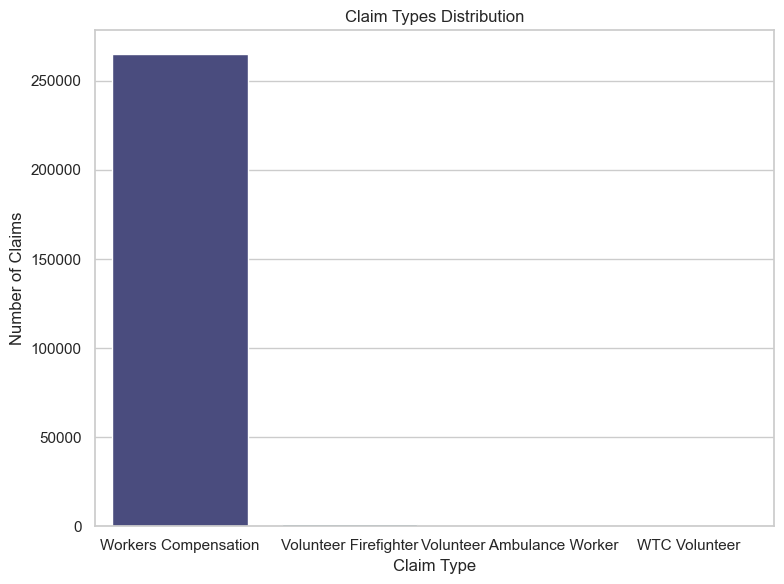

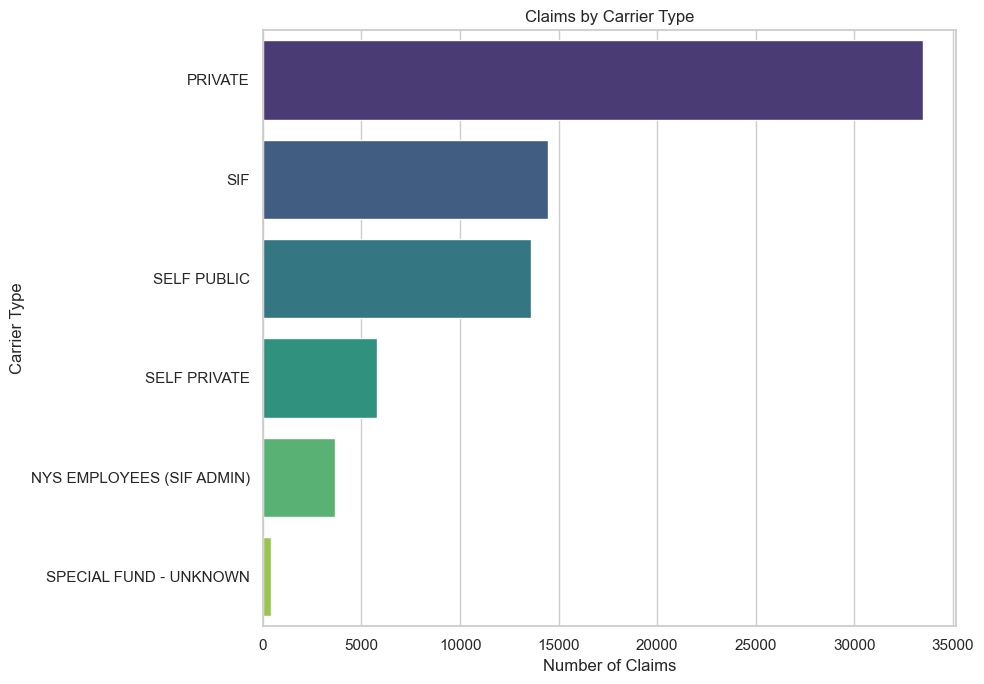

In [76]:
injury_type_counts = df['Claim Injury Type'].value_counts().nlargest(10)
create_barplot(injury_type_counts, "Top 10 Claim Injury Types", "Number of Claims", "Claim Injury Type")

claim_types = df['Claim Type'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=claim_types.index, y=claim_types.values, hue=claim_types.index, 
            palette='viridis', legend=False)
plt.title("Claim Types Distribution")
plt.xlabel("Claim Type")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()

carrier_counts = df['Carrier Type'].value_counts()
create_barplot(carrier_counts, "Claims by Carrier Type", "Number of Claims", "Carrier Type")

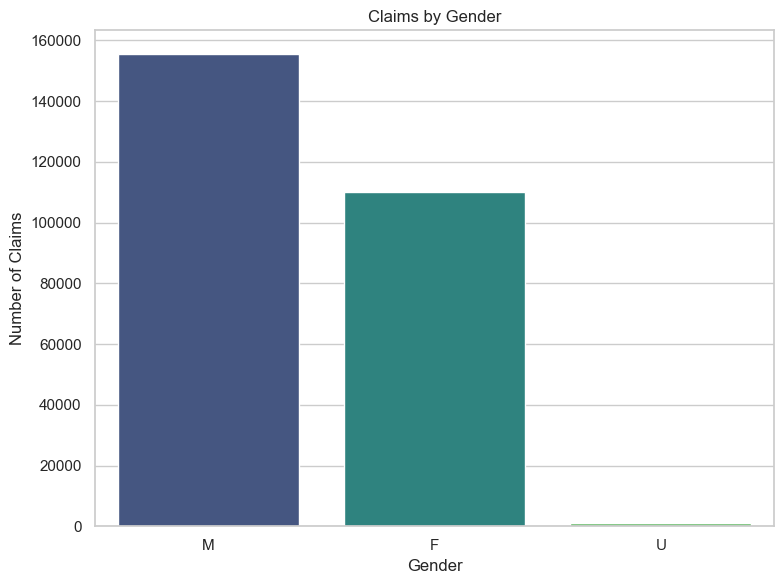

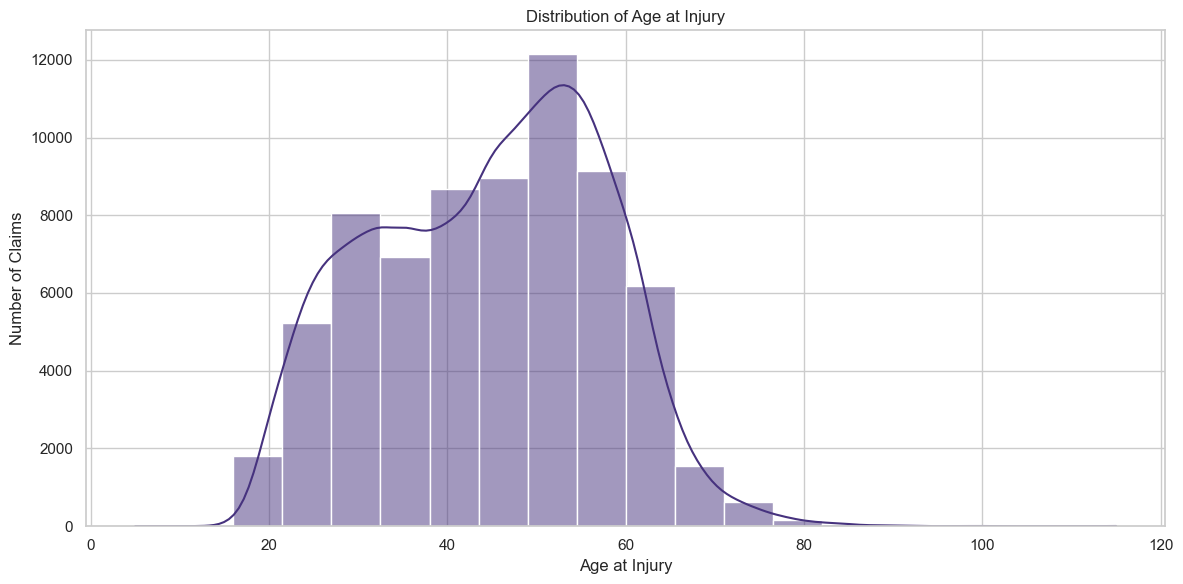

In [77]:
gender_counts = df['Gender'].value_counts()
plt.figure(figsize=(8, 6))
sns.barplot(x=gender_counts.index, y=gender_counts.values, hue=gender_counts.index, 
            palette='viridis', legend=False)
plt.title("Claims by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='Age at Injury', bins=20, kde=True)
plt.title("Distribution of Age at Injury")
plt.xlabel("Age at Injury")
plt.ylabel("Number of Claims")
plt.tight_layout()
plt.show()

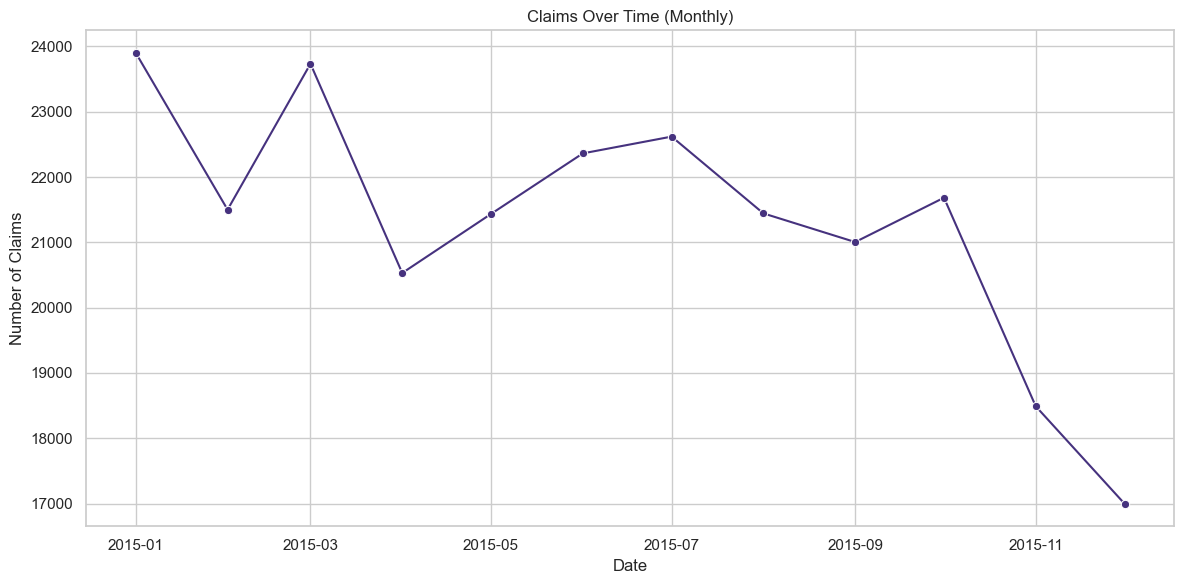

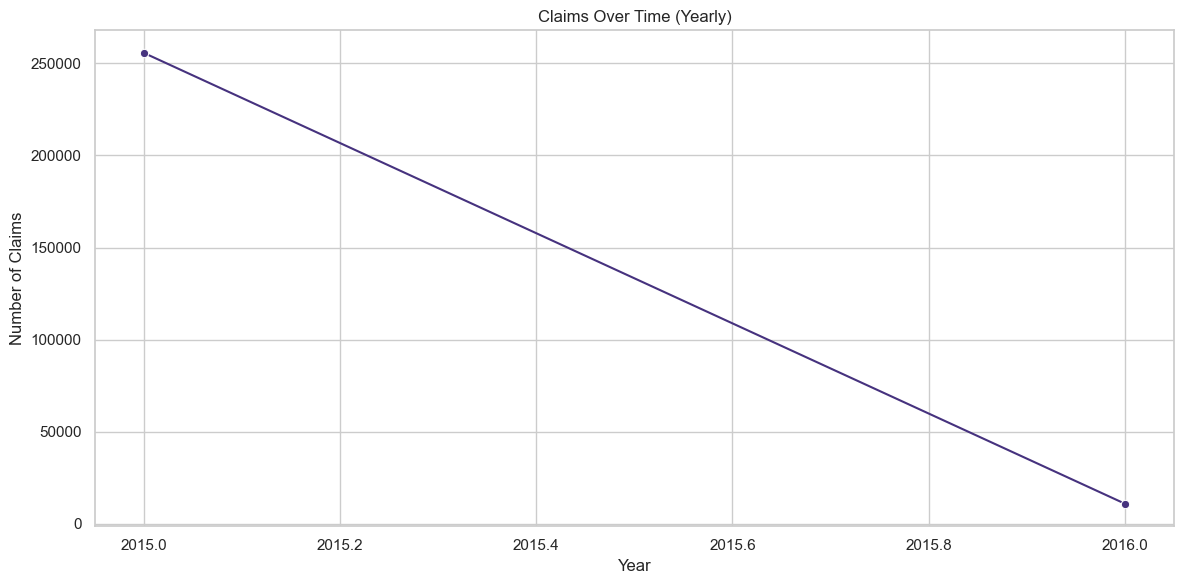

In [78]:
# Construct monthly and yearly claim-count series for temporal inspection.
monthly = df.groupby(["Year", "Month"]).size().reset_index(name="claim_count")
monthly["date"] = pd.to_datetime(monthly[["Year", "Month"]].assign(day=1))
monthly = monthly[monthly["date"] <= "2015-12-31"]

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x="date", y="claim_count", marker='o')
plt.title("Claims Over Time (Monthly)")
plt.ylabel("Number of Claims")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

yearly = df.groupby('Year').size().reset_index(name='claim_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly, x='Year', y='claim_count', marker='o')
plt.title("Claims Over Time (Yearly)")
plt.ylabel("Number of Claims")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

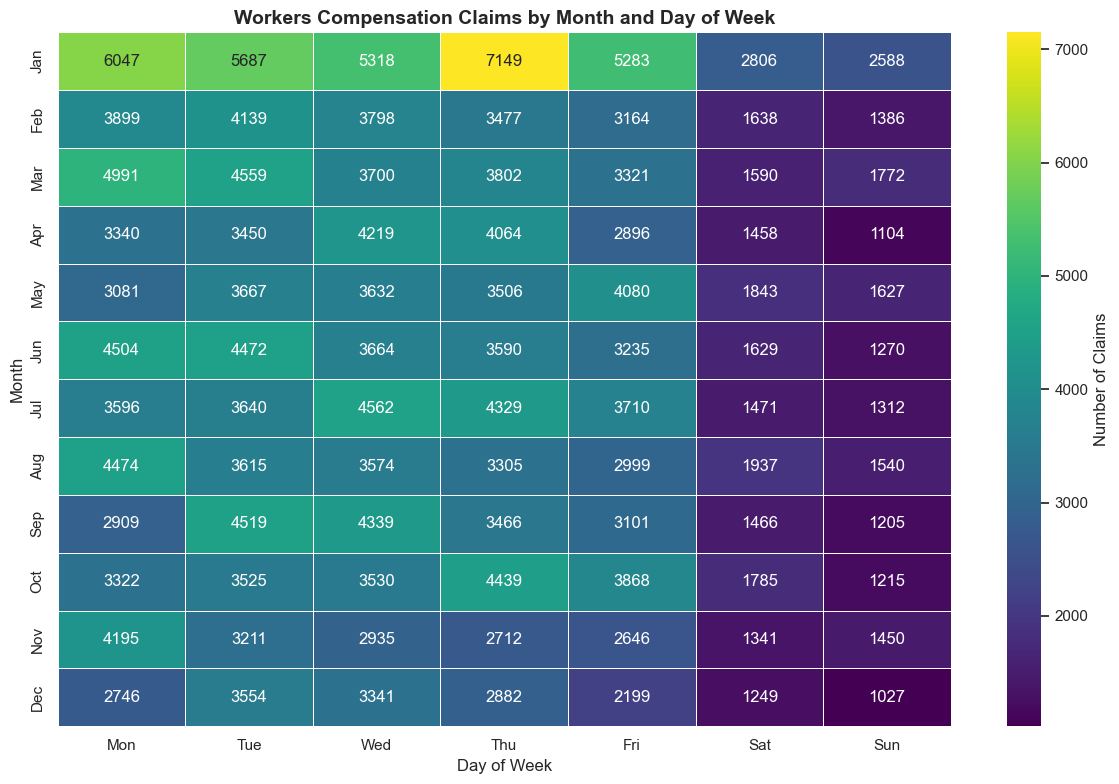

In [79]:
fig, ax = plt.subplots(figsize=(12, 8))

day_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu',
           4: 'Fri', 5: 'Sat', 6: 'Sun'}
month_map = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr',
             5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug',
             9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}

heatmap_data = df.groupby(['Month', 'DayOfWeek']).size().unstack(fill_value=0)
heatmap_data.columns = [day_map[int(i)] for i in heatmap_data.columns]
heatmap_data.index = [month_map[int(i)] for i in heatmap_data.index]

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='viridis', 
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Number of Claims'})
ax.set_title('Workers Compensation Claims by Month and Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week', fontsize=12)
ax.set_ylabel('Month', fontsize=12)
plt.tight_layout()
plt.show()

In [80]:
nature_stats = f"\n{top_nature.to_string()}" if 'WCIO Nature of Injury Description' in df.columns and df['WCIO Nature of Injury Description'].notna().sum() > 0 else "\nNot available or not populated"
body_stats = f"\n{top_body.to_string()}" if 'WCIO Part Of Body Description' in df.columns and df['WCIO Part Of Body Description'].notna().sum() > 0 else "\nNot available or not populated"
event_stats = f"\n{top_event.to_string()}" if 'OIICS Event Exposure Description' in df.columns and df['OIICS Event Exposure Description'].notna().sum() > 0 else "\nNot available or not populated"
source_stats = f"\n{top_source.to_string()}" if 'OIICS Injury Source Description' in df.columns and df['OIICS Injury Source Description'].notna().sum() > 0 else "\nNot available or not populated"

summary = f"""
NY_WC ANALYSIS SUMMARY

Total claims: {len(df):,}
Date range: {df['Accident Date'].min()} to {df['Accident Date'].max()}

Demographics:
- Age at injury (mean): {df['Age at Injury'].mean():.1f} years
- Age at injury (median): {df['Age at Injury'].median():.1f} years
- Gender distribution:
{df['Gender'].value_counts().to_string() if 'Gender' in df.columns else 'Not available'}

Claim Characteristics:
- Average hearing count: {df['Hearing Count'].mean():.2f}
- Carrier types:
{df['Carrier Type'].value_counts().to_string() if 'Carrier Type' in df.columns else 'Not available'}

Top 10 Nature of Injury (WCIO):{nature_stats}

Top 10 Body Parts Injured (WCIO):{body_stats}

Top 10 Event Types (OIICS):{event_stats}

Top 10 Injury Sources (OIICS):{source_stats}

Note: This dataset contains NY workers compensation claims with:
- Daily date information (Accident Date)
- WCIO coding for nature of injury and body parts
- OIICS coding for events and injury sources
- Claim processing information (hearings, carrier type)
- Demographic information (age, gender)

This dataset does NOT contain:
- Severity outcome indicators (hospitalization, amputation, etc.)
- Narrative text fields for natural language processing
- Employer size or specific employer information (may be in hidden columns)
- Industry/NAICS codes (may be in hidden columns not shown in sample)
"""

print(summary)


NY_WC ANALYSIS SUMMARY

Total claims: 266,686
Date range: 2015-01-01 00:00:00 to 2016-06-25 00:00:00

Demographics:
- Age at injury (mean): 44.7 years
- Age at injury (median): 46.0 years
- Gender distribution:
Gender
M    155502
F    109956
U      1228

Claim Characteristics:
- Average hearing count: 0.53
- Carrier types:
Carrier Type
PRIVATE                      33455
SIF                          14466
SELF PUBLIC                  13599
SELF PRIVATE                  5804
NYS EMPLOYEES (SIF ADMIN)     3633
SPECIAL FUND - UNKNOWN         396

Top 10 Nature of Injury (WCIO):
WCIO Nature of Injury Description
STRAIN OR TEAR                      80149
CONTUSION                           45276
LACERATION                          28090
SPRAIN OR TEAR                      23308
ALL OTHER SPECIFIC INJURIES, NOC    17061
FRACTURE                            10832
PUNCTURE                             8451
MULTIPLE PHYSICAL INJURIES ONLY      7102
INFLAMMATION                         6344
FOREIG